Data calling

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving paddy_price_production.csv to paddy_price_production.csv


Data loading

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/paddy_price_production.csv')

# Inspect columns and first few rows
print(df.columns)
df.head()

# Subset data by state
states = df['State'].unique()
print("States in dataset:", states)

# Handle Delhi separately, since production may be missing or zero
delhi = df[df['State'] == 'Delhi'].copy()
other_states = df[df['State'] != 'Delhi']


Index(['Date', 'State', 'Prices', 'Production'], dtype='object')
States in dataset: ['Punjab' 'Delhi' 'West Bengal' 'Tamil Nadu' 'Utar Pradesh']


Intitial data Visualization

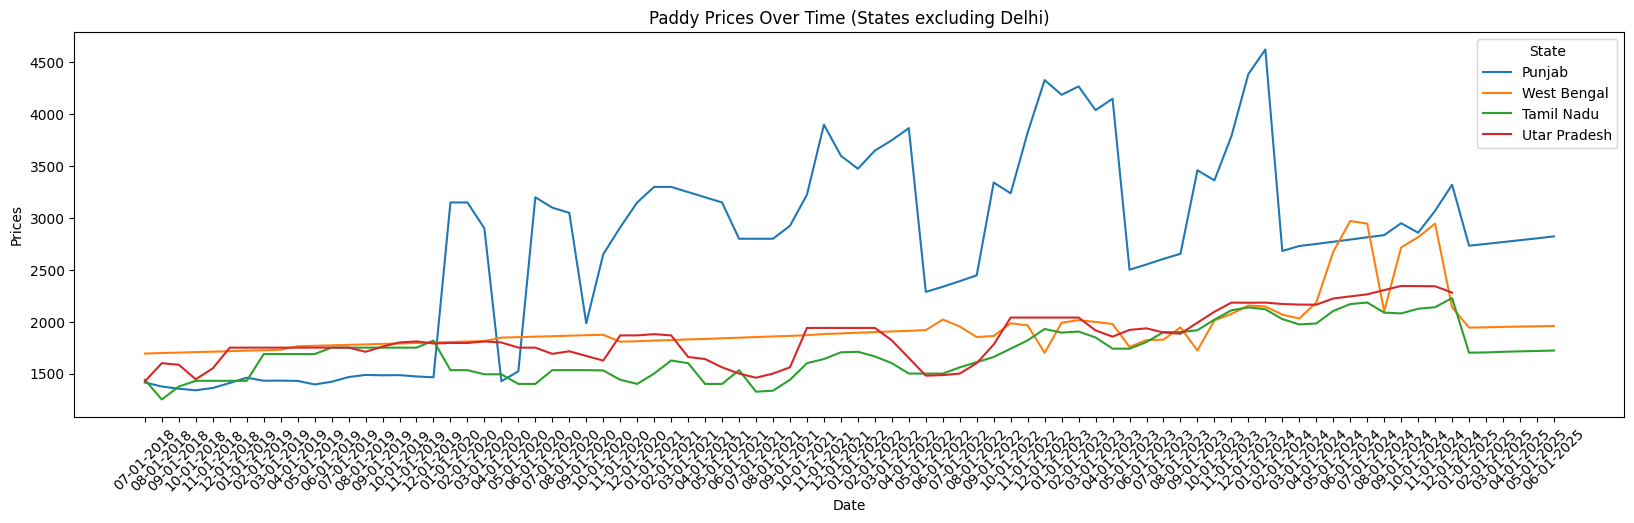

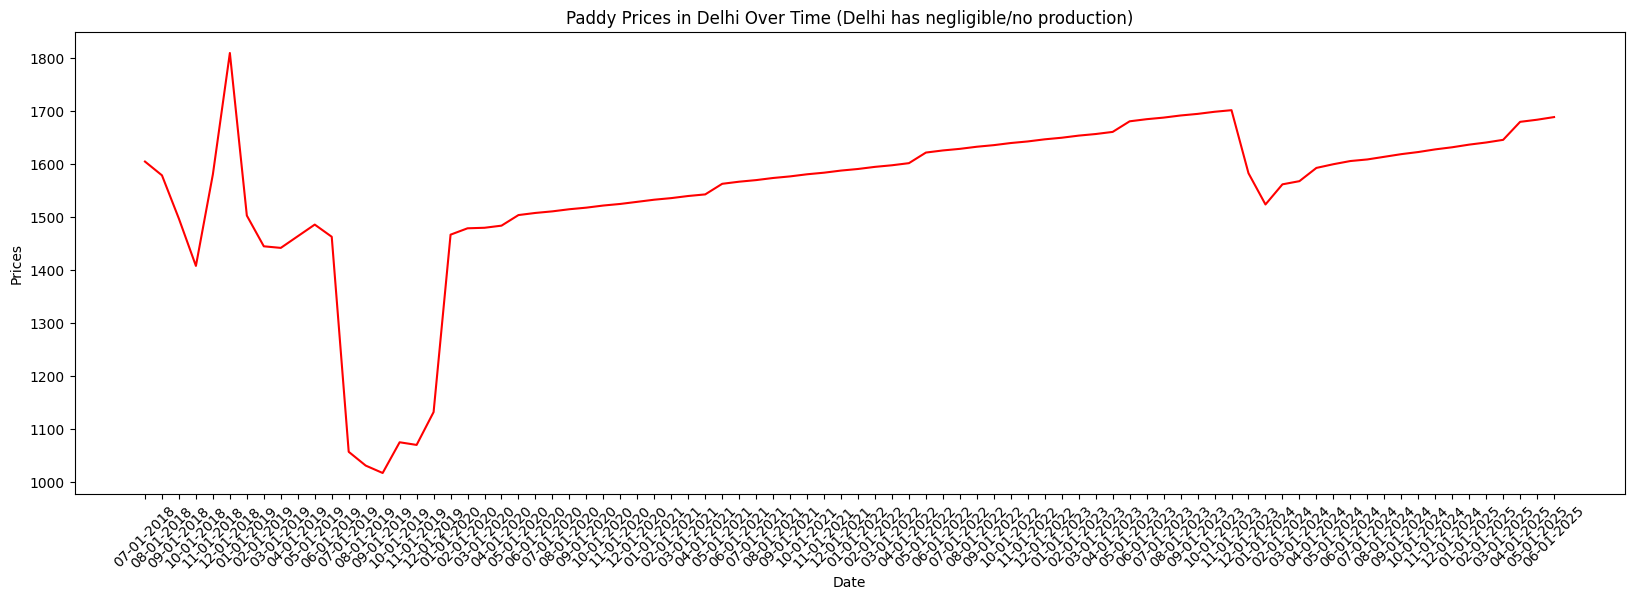

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5))
sns.lineplot(data=other_states, x='Date', y='Prices', hue='State')
plt.xticks(rotation=45)
plt.title("Paddy Prices Over Time (States excluding Delhi)")
plt.show()

# For Delhi, plot only Prices (since Production is not meaningful)
plt.figure(figsize=(20,6))
sns.lineplot(data=delhi, x='Date', y='Prices', color='red')
plt.xticks(rotation=45)
plt.title("Paddy Prices in Delhi Over Time (Delhi has negligible/no production)")
plt.show()


Model Selection via Evaluation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true.values - np.array(y_pred)) / y_true.values)) * 100
    return rmse, mae, mape

def grid_search_arima(series, p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
                      test_size=12, n_splits=3):
    best_score = {'rmse': np.inf, 'mae': np.inf, 'mape': np.inf}
    best_params = None

    n_total = len(series)
    split_indices = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)

    for p in p_range:
        for d in d_range:
            for q in q_range:
                rmse_list, mae_list, mape_list = [], [], []

                for start_train in split_indices:
                    train = series[:start_train]
                    test = series[start_train:start_train + test_size]
                    if len(train) < 12:
                        continue
                    try:
                        model = ARIMA(train, order=(p,d,q))
                        fit = model.fit()
                        preds = fit.forecast(steps=test_size)
                        rmse, mae, mape = evaluate_metrics(test, preds)
                        rmse_list.append(rmse)
                        mae_list.append(mae)
                        mape_list.append(mape)
                    except:
                        continue

                if rmse_list:
                    avg_rmse = np.mean(rmse_list)
                    avg_mae = np.mean(mae_list)
                    avg_mape = np.mean(mape_list)

                    # Check if current model is better on all metrics (strict improvement)
                    if (avg_rmse <= best_score['rmse'] and
                        avg_mae <= best_score['mae'] and
                        avg_mape <= best_score['mape']):
                        best_score = {'rmse': avg_rmse, 'mae': avg_mae, 'mape': avg_mape}
                        best_params = (p,d,q)
    return best_params, best_score

def grid_search_sarima(series, p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
                       P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2), m=12,
                       test_size=12, n_splits=3):
    best_score = {'rmse': np.inf, 'mae': np.inf, 'mape': np.inf}
    best_params = None

    n_total = len(series)
    split_indices = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)

    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            rmse_list, mae_list, mape_list = [], [], []
                            for start_train in split_indices:
                                train = series[:start_train]
                                test = series[start_train:start_train + test_size]
                                if len(train) < 24:
                                    continue
                                try:
                                    model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m))
                                    fit = model.fit(disp=False)
                                    preds = fit.forecast(steps=test_size)
                                    rmse, mae, mape = evaluate_metrics(test, preds)
                                    rmse_list.append(rmse)
                                    mae_list.append(mae)
                                    mape_list.append(mape)
                                except:
                                    continue
                            if rmse_list:
                                avg_rmse = np.mean(rmse_list)
                                avg_mae = np.mean(mae_list)
                                avg_mape = np.mean(mape_list)
                                if (avg_rmse <= best_score['rmse'] and
                                    avg_mae <= best_score['mae'] and
                                    avg_mape <= best_score['mape']):
                                    best_score = {'rmse': avg_rmse, 'mae': avg_mae, 'mape': avg_mape}
                                    best_params = (p,d,q,P,D,Q)
    return best_params, best_score

def grid_search_sarimax(series, exog_series, p_range=range(0,2), d_range=range(0,2), q_range=range(0,2),
                        P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2), m=12,
                        test_size=12, n_splits=3):
    best_score = {'rmse': np.inf, 'mae': np.inf, 'mape': np.inf}
    best_params = None

    n_total = len(series)
    split_indices = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)

    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            rmse_list, mae_list, mape_list = [], [], []
                            for start_train in split_indices:
                                train_end = start_train
                                test_end = train_end + test_size
                                train = series[:train_end]
                                test = series[train_end:test_end]
                                exog_train = exog_series[:train_end]
                                exog_test = exog_series[train_end:test_end]
                                if len(train) < 24 or exog_train.isnull().any():
                                    continue
                                try:
                                    model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m), exog=exog_train)
                                    fit = model.fit(disp=False)
                                    preds = fit.forecast(steps=test_size, exog=exog_test)
                                    rmse, mae, mape = evaluate_metrics(test, preds)
                                    rmse_list.append(rmse)
                                    mae_list.append(mae)
                                    mape_list.append(mape)
                                except:
                                    continue
                            if rmse_list:
                                avg_rmse = np.mean(rmse_list)
                                avg_mae = np.mean(mae_list)
                                avg_mape = np.mean(mape_list)
                                if (avg_rmse <= best_score['rmse'] and
                                    avg_mae <= best_score['mae'] and
                                    avg_mape <= best_score['mape']):
                                    best_score = {'rmse': avg_rmse, 'mae': avg_mae, 'mape': avg_mape}
                                    best_params = (p,d,q,P,D,Q)
    return best_params, best_score

# Main execution - Load and preprocess data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

states = df['State'].unique()
results = []
best_model_per_state = {}

for state in states:
    print(f"\nProcessing {state}")
    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'

    # Production might be used as exog for SARIMAX
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    if len(price_series) < 36:
        print(f"Skipping {state}: insufficient data")
        continue

    # ARIMA
    print("  Tuning ARIMA...")
    arima_params, arima_score = grid_search_arima(price_series)
    print(f"  Best ARIMA: params={arima_params}, RMSE={arima_score['rmse']:.2f}, MAE={arima_score['mae']:.2f}, MAPE={arima_score['mape']:.2f}%")

    # SARIMA
    print("  Tuning SARIMA...")
    sarima_params, sarima_score = grid_search_sarima(price_series)
    print(f"  Best SARIMA: params={sarima_params}, RMSE={sarima_score['rmse']:.2f}, MAE={sarima_score['mae']:.2f}, MAPE={sarima_score['mape']:.2f}%")

    # SARIMAX (only if production is valid and aligned)
    sarimax_params, sarimax_score = None, {'rmse': np.inf, 'mae': np.inf, 'mape': np.inf}
    if len(production_series) == len(price_series) and not production_series.isnull().any():
        print("  Tuning SARIMAX...")
        sarimax_params, sarimax_score = grid_search_sarimax(price_series, production_series)
        print(f"  Best SARIMAX: params={sarimax_params}, RMSE={sarimax_score['rmse']:.2f}, MAE={sarimax_score['mae']:.2f}, MAPE={sarimax_score['mape']:.2f}%")
    else:
        print(f"  SARIMAX: Skipped (insufficient production data for {state})")

    # Add all three models to results
    results.append({
        'State': state,
        'Model_Type': 'ARIMA',
        'Best_Params': arima_params,
        'RMSE': arima_score['rmse'],
        'MAE': arima_score['mae'],
        'MAPE': arima_score['mape']
    })

    results.append({
        'State': state,
        'Model_Type': 'SARIMA',
        'Best_Params': sarima_params,
        'RMSE': sarima_score['rmse'],
        'MAE': sarima_score['mae'],
        'MAPE': sarima_score['mape']
    })

    if sarimax_params is not None:
        results.append({
            'State': state,
            'Model_Type': 'SARIMAX',
            'Best_Params': sarimax_params,
            'RMSE': sarimax_score['rmse'],
            'MAE': sarimax_score['mae'],
            'MAPE': sarimax_score['mape']
        })

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("SUMMARY - Best ARIMA, SARIMA, and SARIMAX for each state:")
print("="*100)
print(results_df.to_string(index=False))

# Optional: Display by model type
print("\n" + "="*100)
print("GROUPED BY MODEL TYPE:")
print("="*100)
for model_type in ['ARIMA', 'SARIMA', 'SARIMAX']:
    print(f"\n{model_type}:")
    print(results_df[results_df['Model_Type'] == model_type].to_string(index=False))



Processing Punjab
  Tuning ARIMA...
  Best ARIMA: params=(0, 1, 2), RMSE=580.93, MAE=516.74, MAPE=15.35%
  Tuning SARIMA...
  Best SARIMA: params=(2, 0, 0, 0, 1, 0), RMSE=616.11, MAE=415.44, MAPE=13.65%
  Tuning SARIMAX...
  Best SARIMAX: params=(0, 0, 1, 1, 0, 0), RMSE=66.52, MAE=57.30, MAPE=1.68%

Processing Utar Pradesh
  Tuning ARIMA...
  Best ARIMA: params=(2, 1, 2), RMSE=137.81, MAE=120.73, MAPE=6.16%
  Tuning SARIMA...
  Best SARIMA: params=(1, 1, 2, 0, 1, 0), RMSE=130.59, MAE=99.22, MAPE=5.05%
  SARIMAX: Skipped (insufficient production data for Utar Pradesh)

Processing Delhi
  Tuning ARIMA...
  Best ARIMA: params=(1, 1, 1), RMSE=53.05, MAE=41.85, MAPE=2.59%
  Tuning SARIMA...
  Best SARIMA: params=(2, 1, 2, 1, 0, 0), RMSE=48.35, MAE=39.90, MAPE=2.46%
  Tuning SARIMAX...
  Best SARIMAX: params=(0, 1, 0, 1, 0, 0), RMSE=48.63, MAE=40.10, MAPE=2.48%

Processing West Bengal
  Tuning ARIMA...
  Best ARIMA: params=(0, 0, 2), RMSE=355.74, MAE=252.63, MAPE=10.51%
  Tuning SARIMA...
 


ACF and PACF side-by-side for Punjab


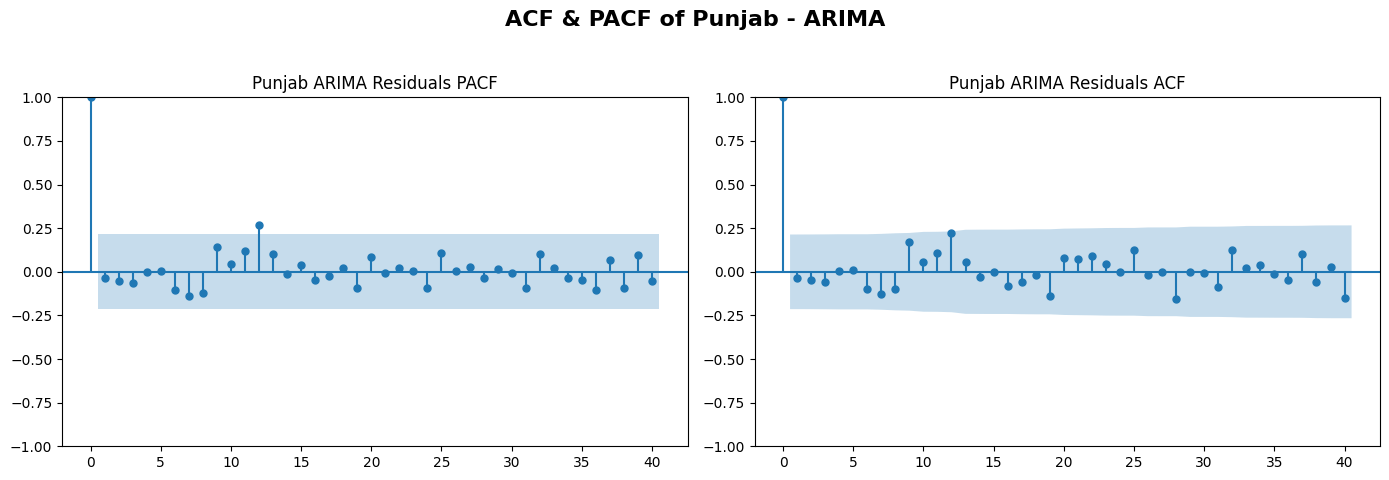

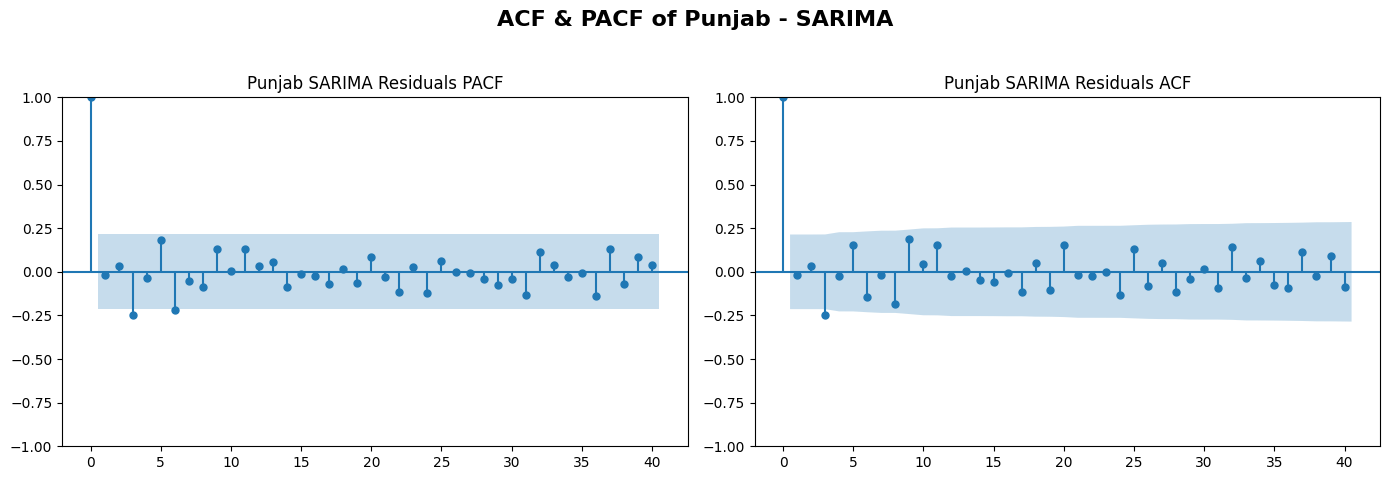

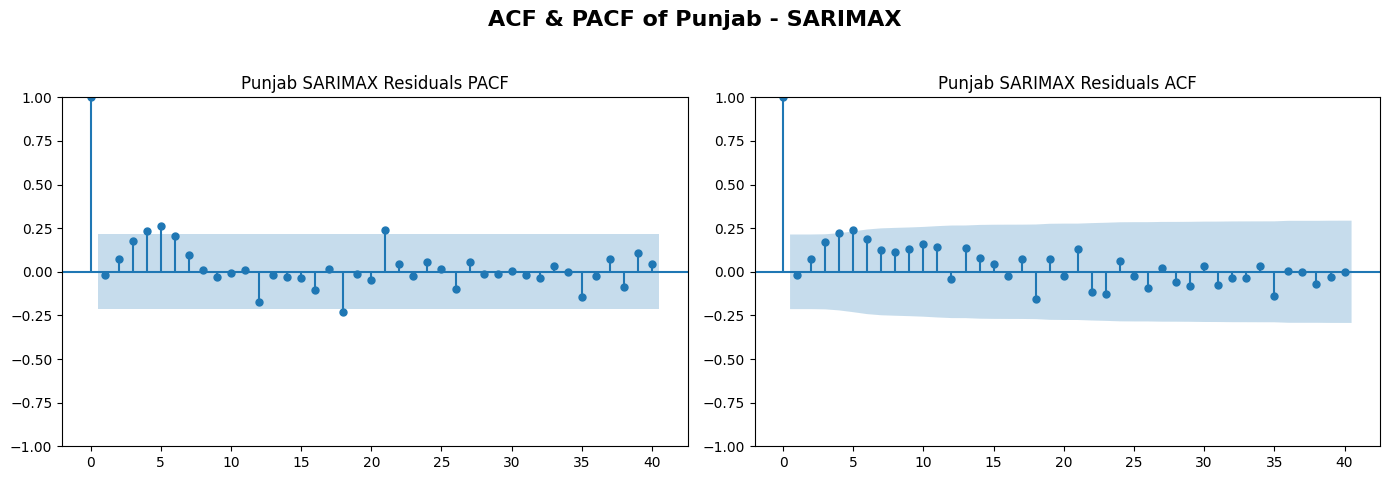


ACF and PACF side-by-side for Utar Pradesh


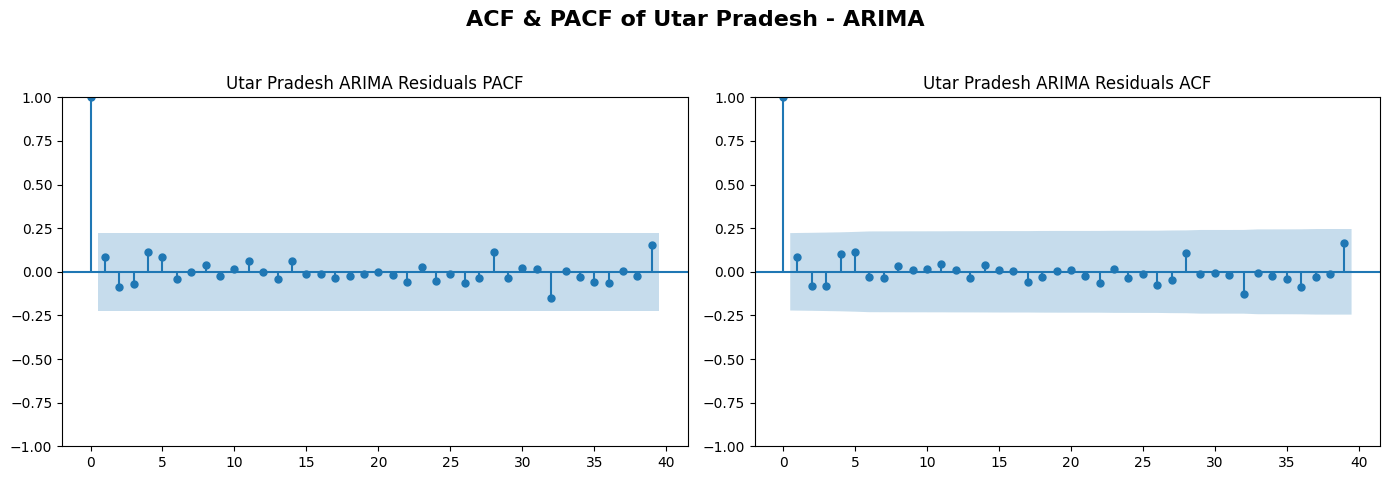

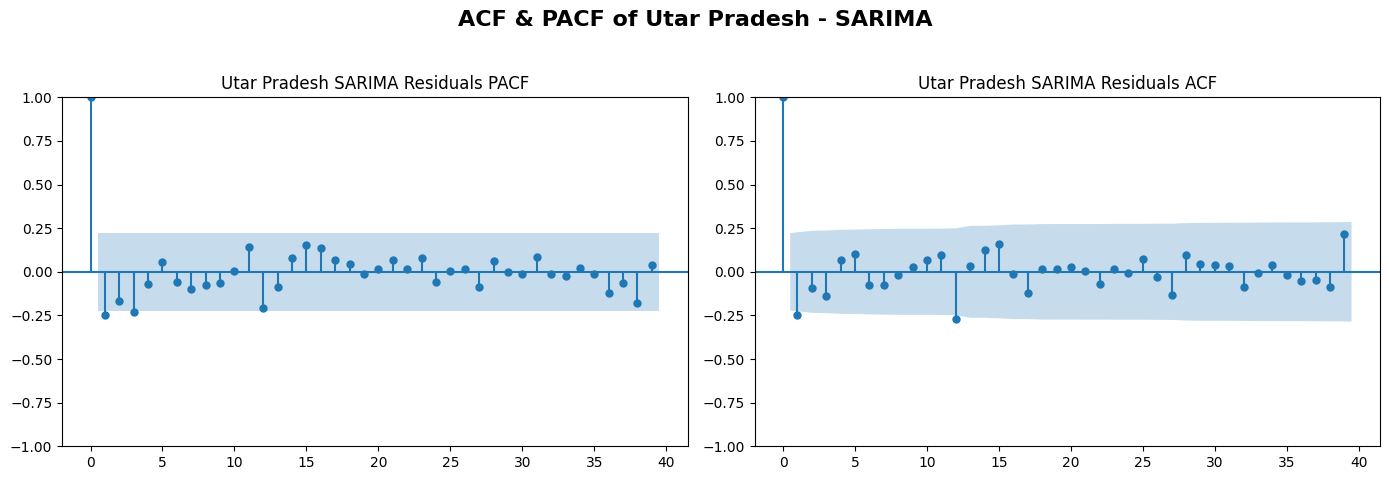

Utar Pradesh SARIMAX: Skipped (no valid production data)

ACF and PACF side-by-side for Delhi


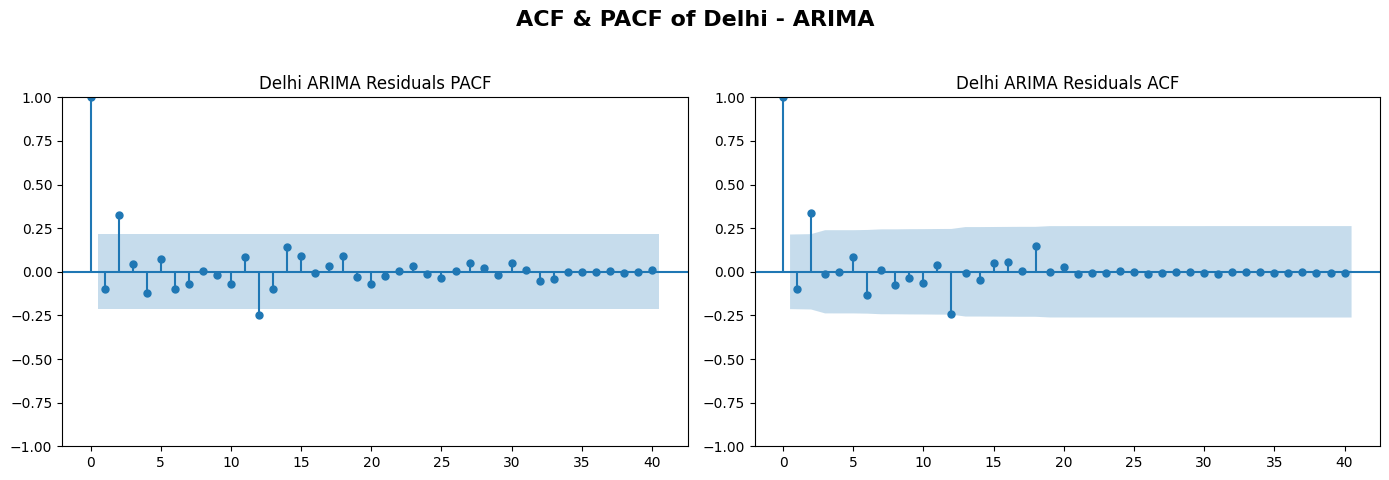

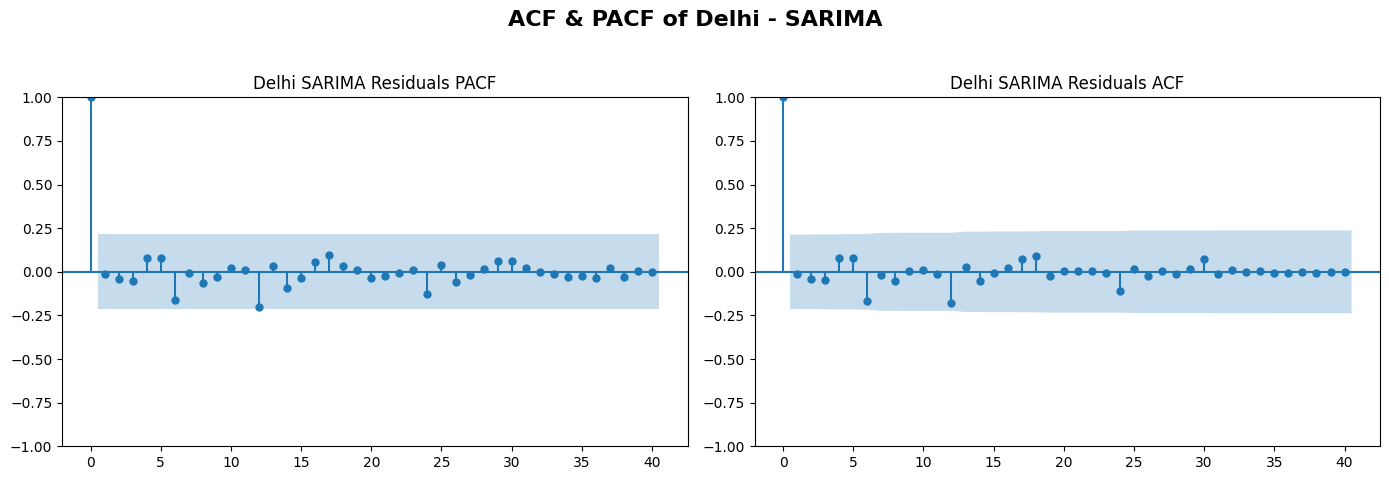

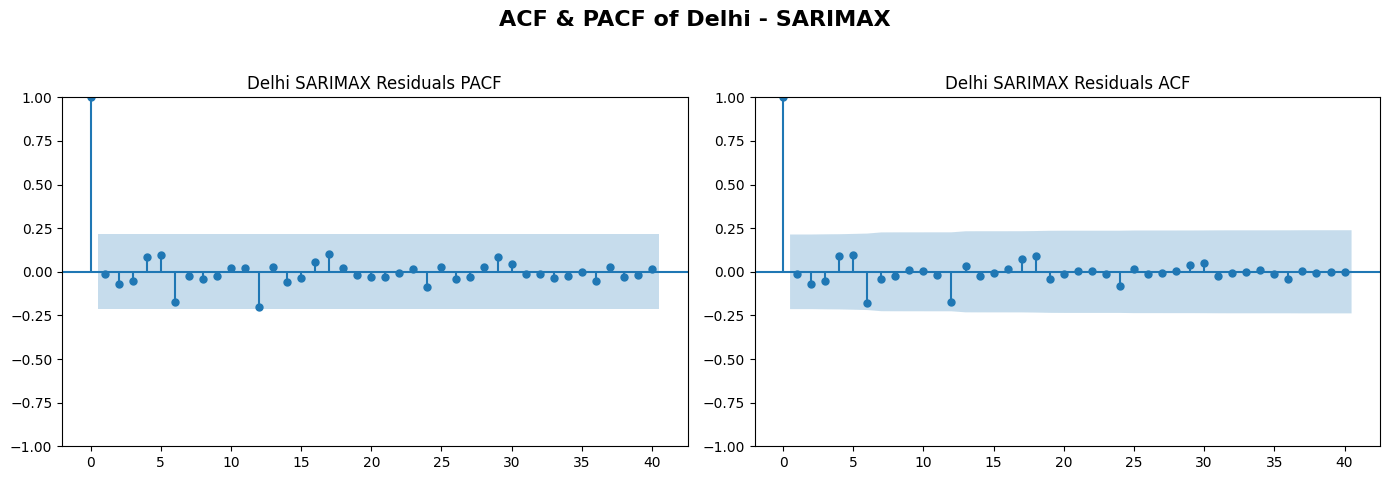


ACF and PACF side-by-side for West Bengal


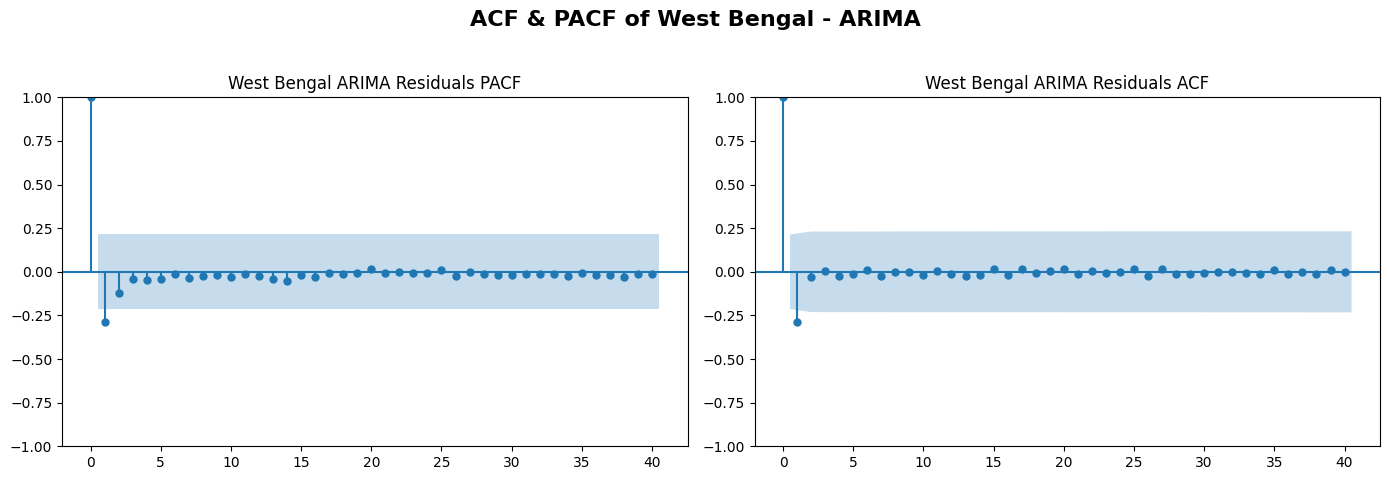

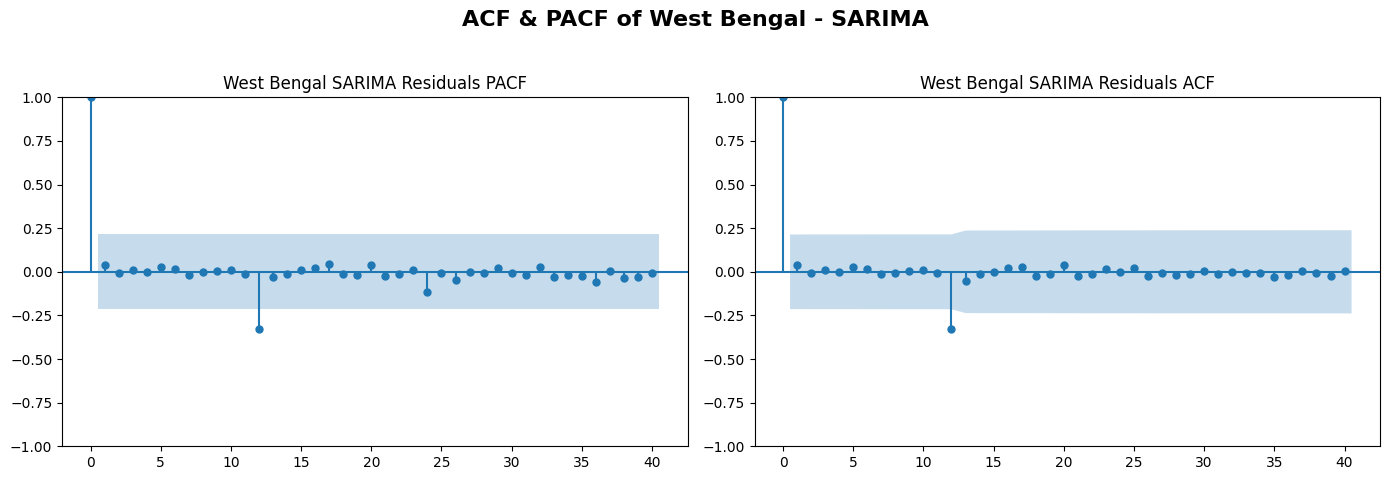

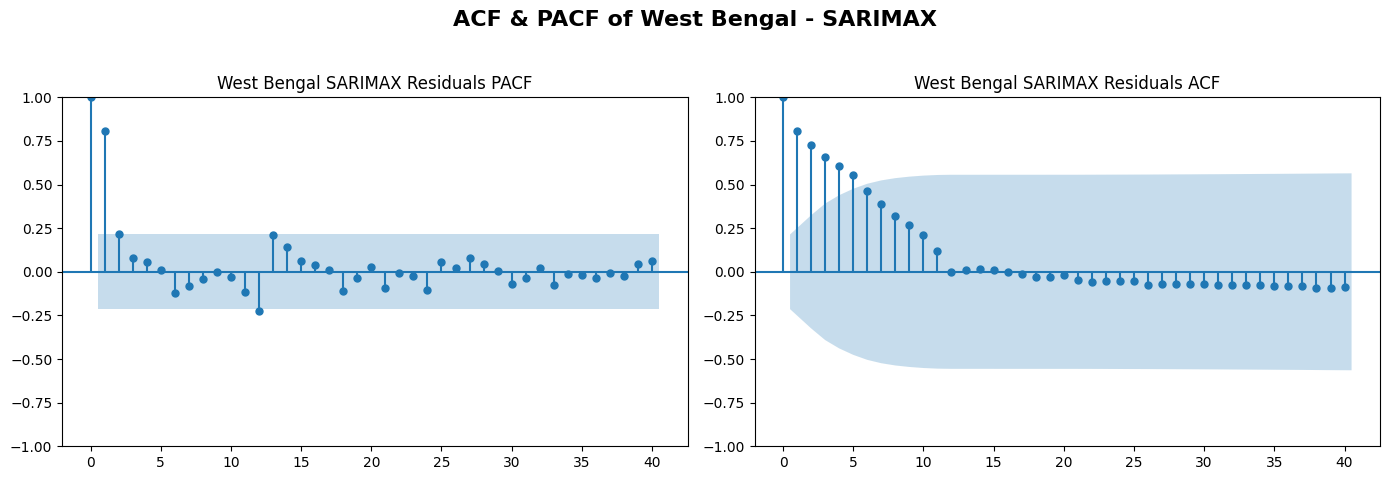


ACF and PACF side-by-side for Tamil Nadu


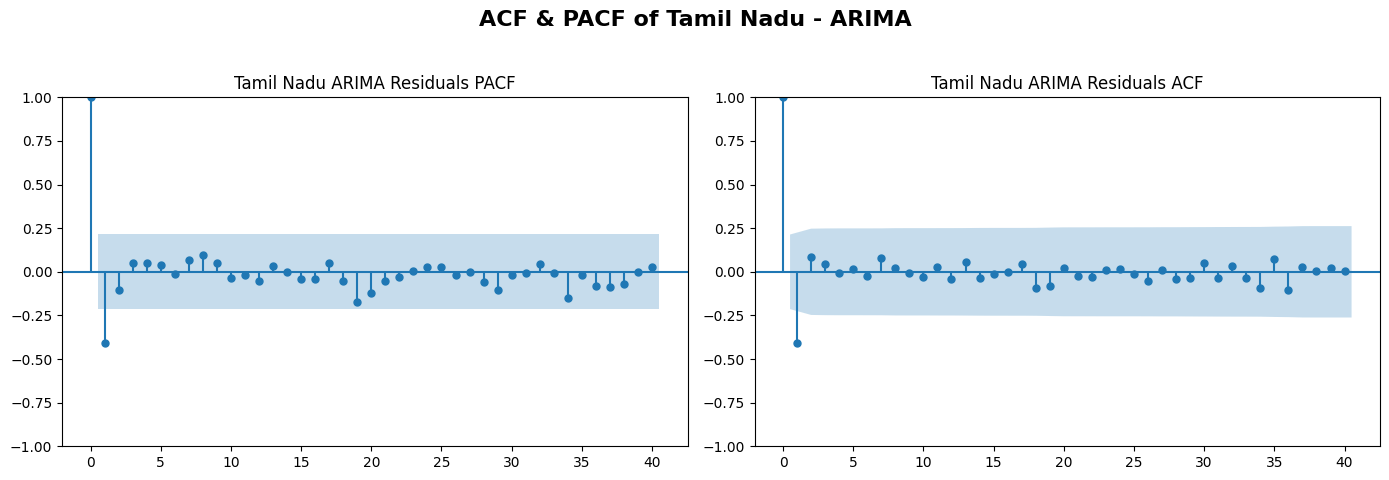

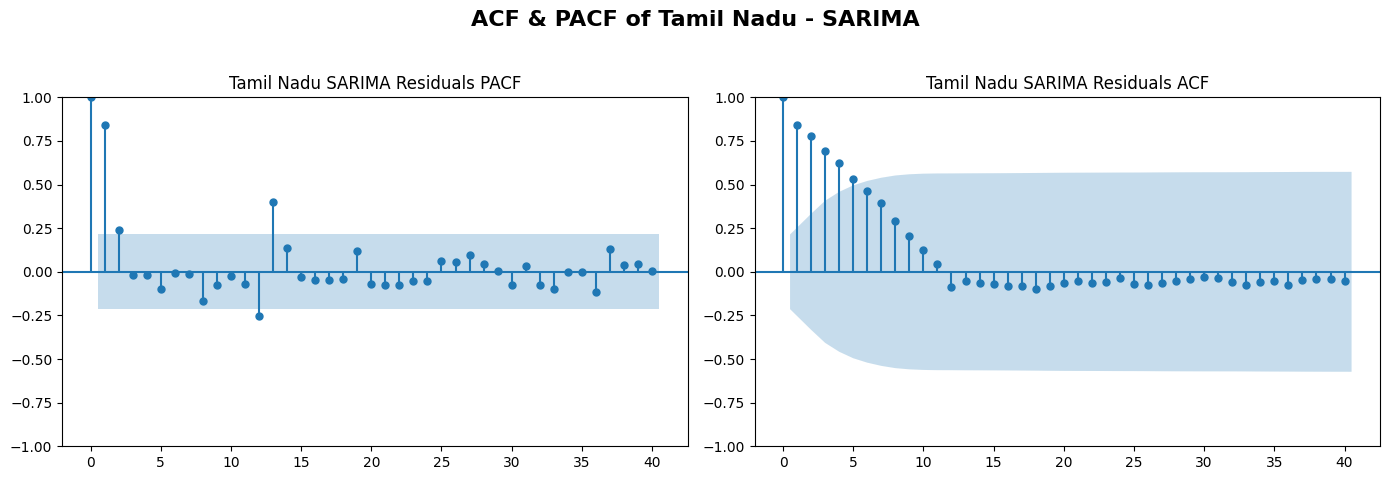

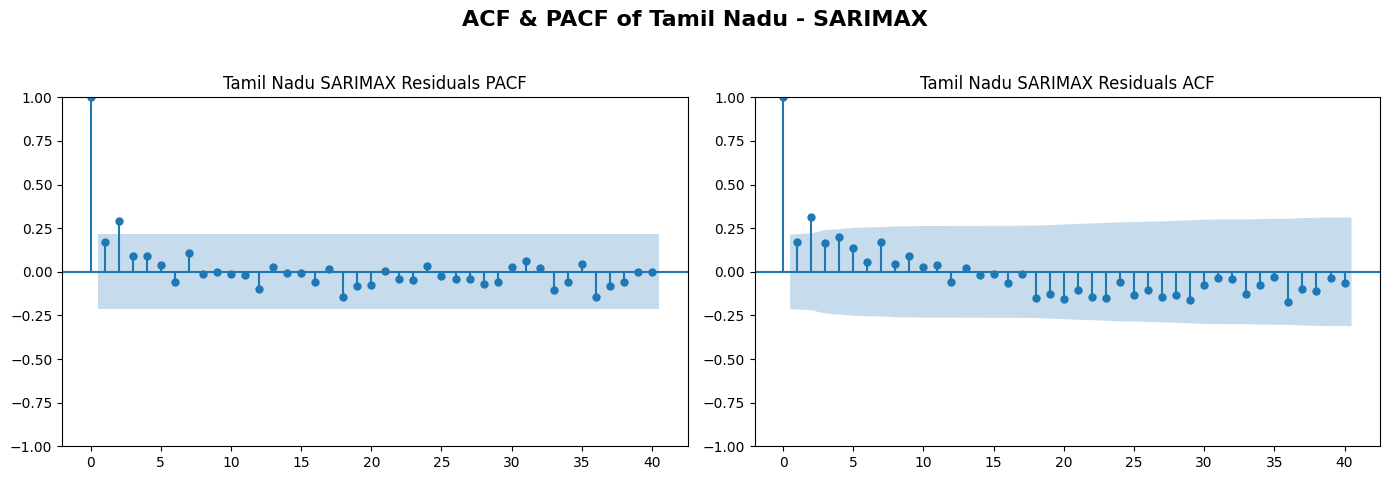

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Best model parameters
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (1, 2, 4, 1, 1, 2), 'SARIMAX': (0, 0, 3, 1, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (0, 2, 5, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (8, 1, 4), 'SARIMA': (3, 0, 0, 1, 0, 0), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (14, 2, 13), 'SARIMA': (2, 1, 5, 2, 1, 1), 'SARIMAX': (2, 0, 2, 1, 1, 0)}, # Updated SARIMAX params
    'Tamil Nadu': {'ARIMA': (9, 2, 15), 'SARIMA': (2, 0, 1, 0, 1, 0), 'SARIMAX': (1, 0, 2, 1, 0, 2)}
}

df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

states = df['State'].unique()


def plot_acf_pacf_side_by_side(residuals, model_name, state):
    max_lag = min(40, len(residuals) // 2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PACF on left
    plot_pacf(residuals, lags=max_lag, ax=axes[0], method='ywm', title=f"{state} {model_name} Residuals PACF")

    # ACF on right
    plot_acf(residuals, lags=max_lag, ax=axes[1], title=f"{state} {model_name} Residuals ACF")
    fig.subplots_adjust(wspace=0.4)
    fig.suptitle(f"ACF & PACF of {state} - {model_name}", fontsize=16, fontweight='bold')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()


for state in states:
    print(f"\n{'=' * 80}")
    print(f"ACF and PACF side-by-side for {state}")
    print(f"{'=' * 80}")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    # ARIMA residuals
    arima_param = best_params[state]['ARIMA']
    arima_model = ARIMA(price_series, order=arima_param)
    arima_fit = arima_model.fit()
    arima_resid = arima_fit.resid.dropna()
    plot_acf_pacf_side_by_side(arima_resid, 'ARIMA', state)

    # SARIMA residuals
    sarima_param = best_params[state]['SARIMA']
    sarima_model = SARIMAX(price_series, order=sarima_param[:3], seasonal_order=sarima_param[3:] + (12,))
    sarima_fit = sarima_model.fit(disp=False)
    sarima_resid = sarima_fit.resid.dropna()
    plot_acf_pacf_side_by_side(sarima_resid, 'SARIMA', state)

    # SARIMAX residuals if valid production
    sarimax_param = best_params[state]['SARIMAX']
    if sarimax_param is not None and len(production_series) == len(price_series):
        sarimax_model = SARIMAX(price_series, order=sarimax_param[:3], seasonal_order=sarimax_param[3:] + (12,),
                               exog=production_series)
        sarimax_fit = sarimax_model.fit(disp=False)
        sarimax_resid = sarimax_fit.resid.dropna()
        plot_acf_pacf_side_by_side(sarimax_resid, 'SARIMAX', state)
    else:
        print(f"{state} SARIMAX: Skipped (no valid production data)")


 Forecasting and Visualization



################################################################################
# GENERATING FORECASTS FOR PUNJAB
################################################################################


********************************************************************************
* ARIMA MODEL FOR Punjab
********************************************************************************

Punjab - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2848.82
            2 Aug 2025                      2900.94
            3 Sep 2025                      2869.67
            4 Oct 2025                      2897.14
            5 Nov 2025                      2876.62
            6 Dec 2025                      2891.95
            7 Jan 2026                      2880.50
            8 Feb 2026                      2889.06
            9 Mar 2026                      2882.66
           10 Apr 2026                      2

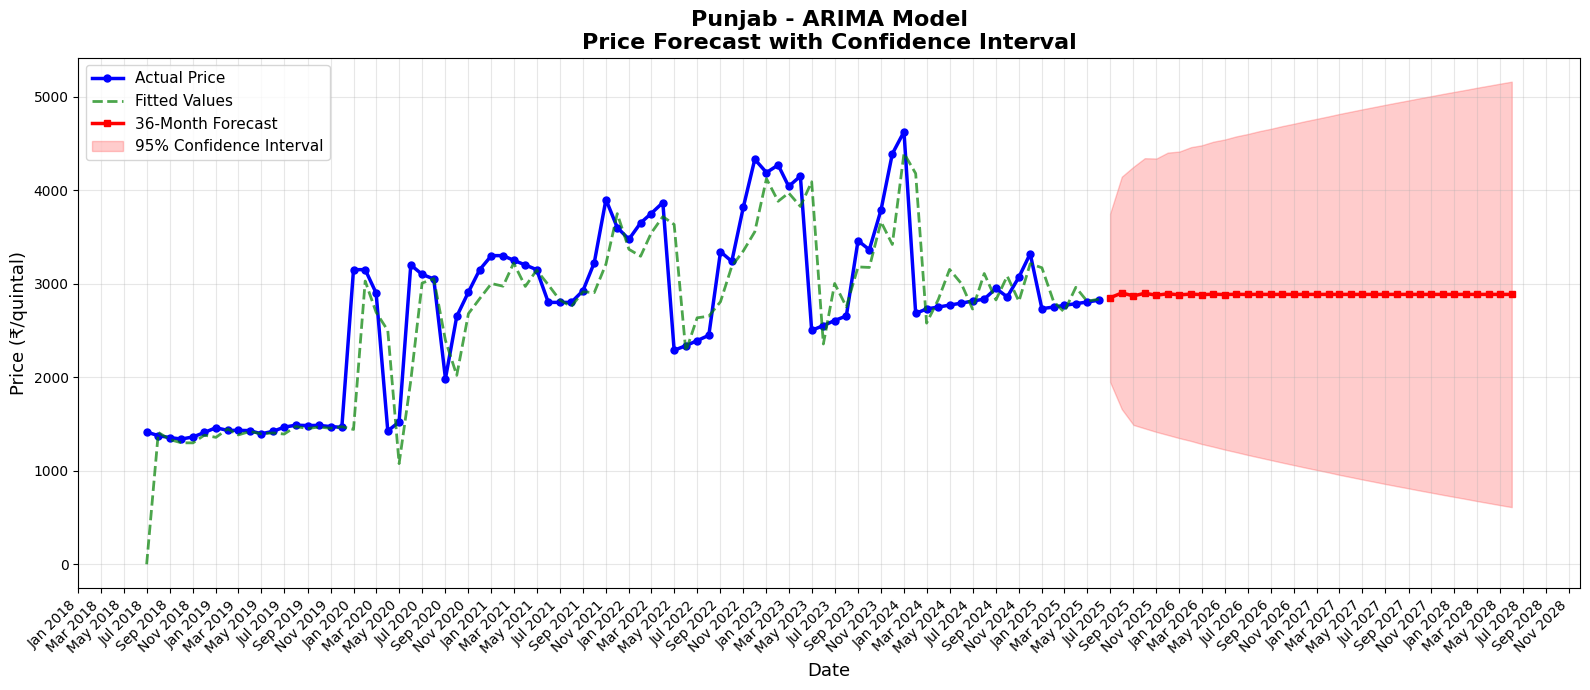


********************************************************************************
* SARIMA MODEL FOR Punjab
********************************************************************************

Punjab - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2867.82
            2 Aug 2025                      2728.52
            3 Sep 2025                      2879.00
            4 Oct 2025                      2914.37
            5 Nov 2025                      3161.01
            6 Dec 2025                      3418.51
            7 Jan 2026                      3253.61
            8 Feb 2026                      2985.85
            9 Mar 2026                      2952.90
           10 Apr 2026                      2891.45
           11 May 2026                      2616.00
           12 Jun 2026                      2756.98
           13 Jul 2026                      2807.51
           14 Aug 2026            

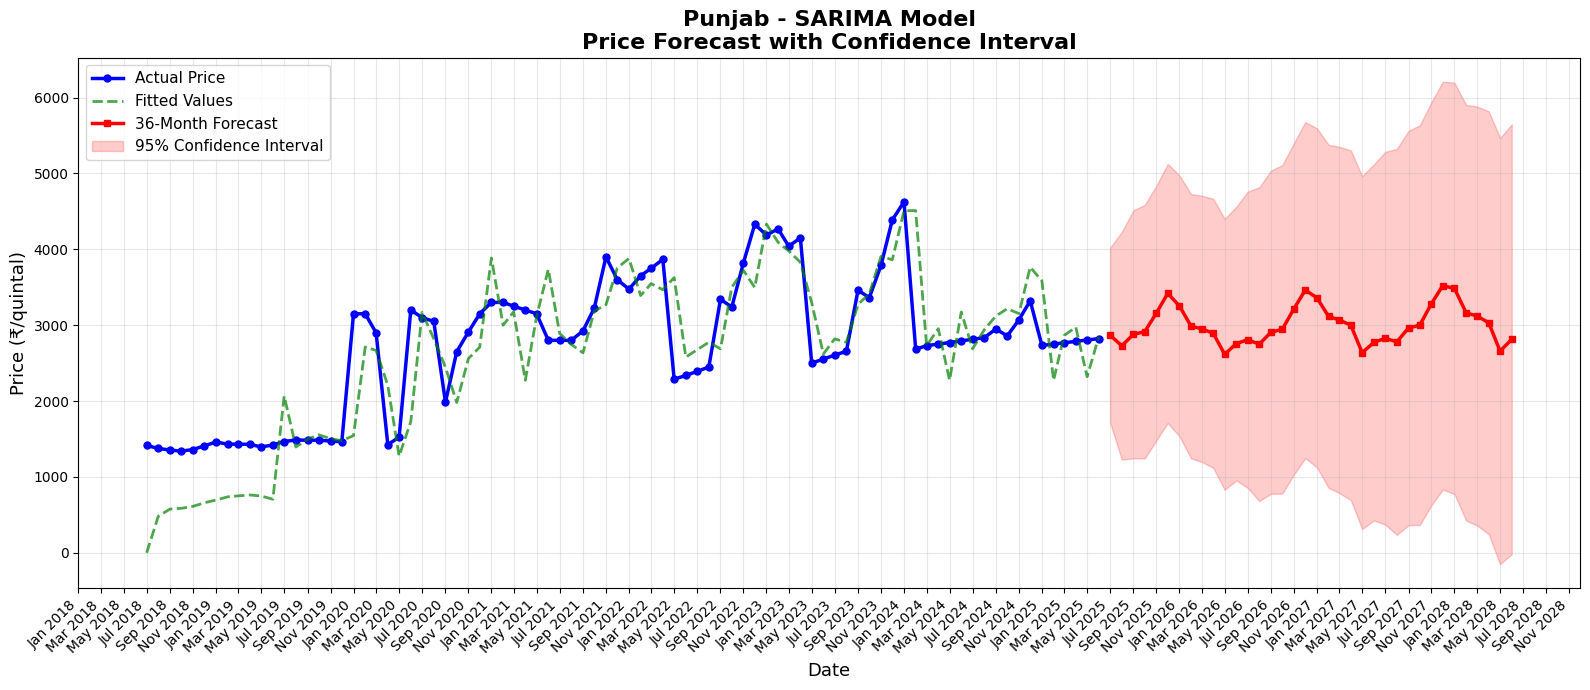


********************************************************************************
* SARIMAX MODEL FOR Punjab
********************************************************************************

Punjab - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2831.17
            2 Aug 2025                      2822.46
            3 Sep 2025                      2808.25
            4 Oct 2025                      2805.78
            5 Nov 2025                      2808.24
            6 Dec 2025                      2807.06
            7 Jan 2026                      2805.32
            8 Feb 2026                      2806.03
            9 Mar 2026                      2806.48
           10 Apr 2026                      2806.84
           11 May 2026                      2807.29
           12 Jun 2026                      2807.92
           13 Jul 2026                      2808.62
           14 Aug 2026          

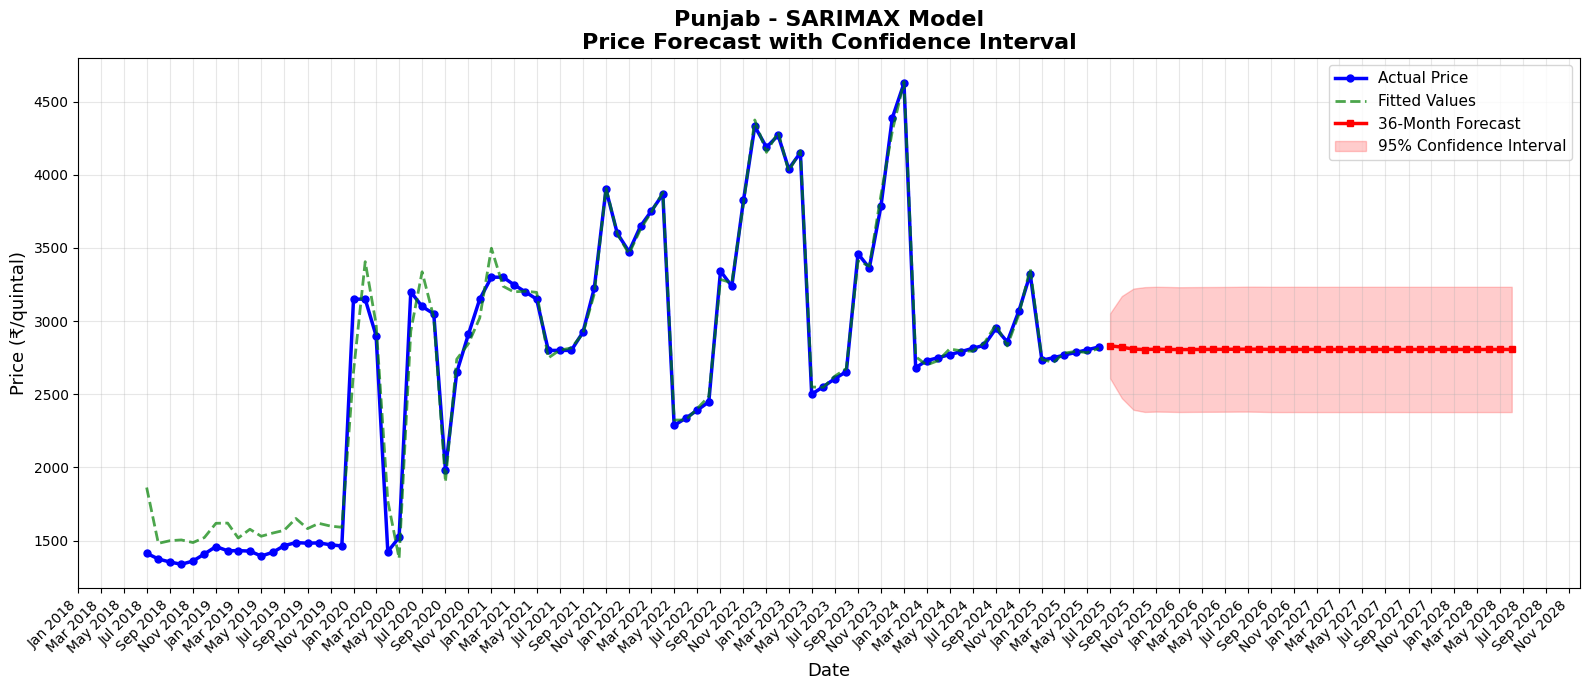



################################################################################
# GENERATING FORECASTS FOR UTAR PRADESH
################################################################################


********************************************************************************
* ARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2269.13
            2 Feb 2025                      2263.54
            3 Mar 2025                      2265.12
            4 Apr 2025                      2272.88
            5 May 2025                      2284.35
            6 Jun 2025                      2296.33
            7 Jul 2025                      2305.76
            8 Aug 2025                      2310.47
            9 Sep 2025                      2309.67
           10 Oct 2025     

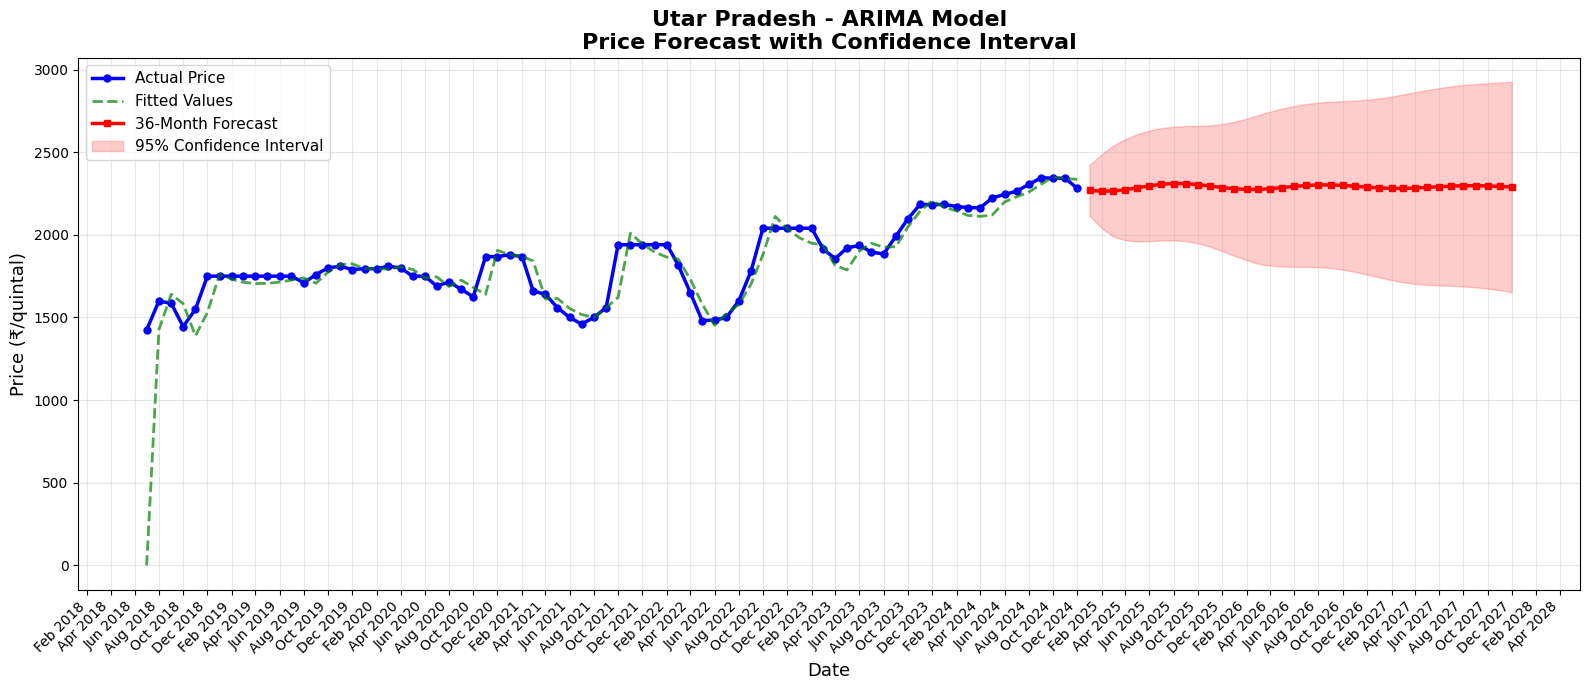


********************************************************************************
* SARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2325.75
            2 Feb 2025                      2358.18
            3 Mar 2025                      2375.91
            4 Apr 2025                      2383.77
            5 May 2025                      2435.08
            6 Jun 2025                      2446.40
            7 Jul 2025                      2457.72
            8 Aug 2025                      2490.04
            9 Sep 2025                      2521.36
           10 Oct 2025                      2510.68
           11 Nov 2025                      2501.00
           12 Dec 2025                      2431.31
           13 Jan 2026                      2467.39
           14 Feb 2026

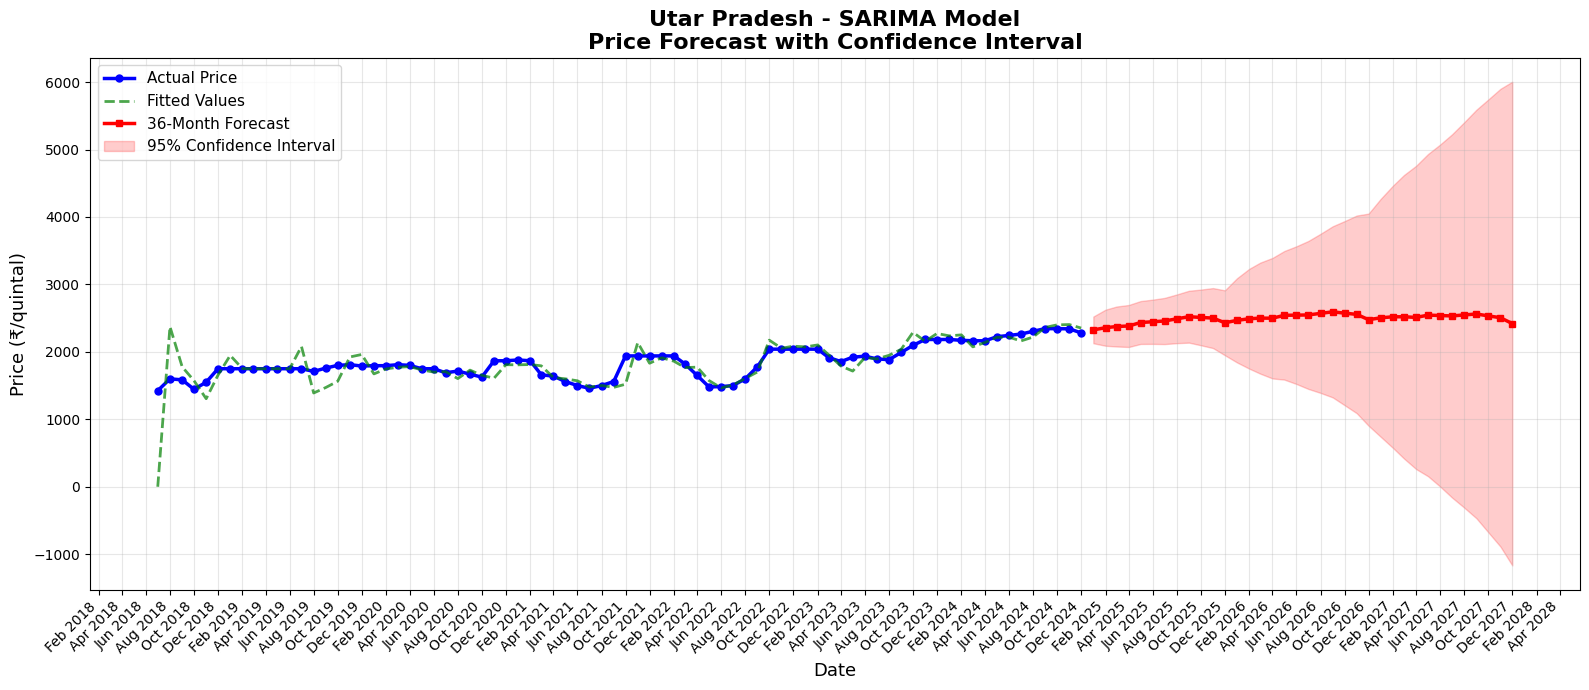


********************************************************************************
* SARIMAX MODEL FOR Utar Pradesh - SKIPPED
* Reason: No production data available for this state
********************************************************************************


################################################################################
# GENERATING FORECASTS FOR DELHI
################################################################################


********************************************************************************
* ARIMA MODEL FOR Delhi
********************************************************************************

Delhi - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1705.77
            2 Aug 2025                      1721.60
            3 Sep 2025                      1708.04
            4 Oct 2025                      1686.44
            5 Nov 2025                      1697

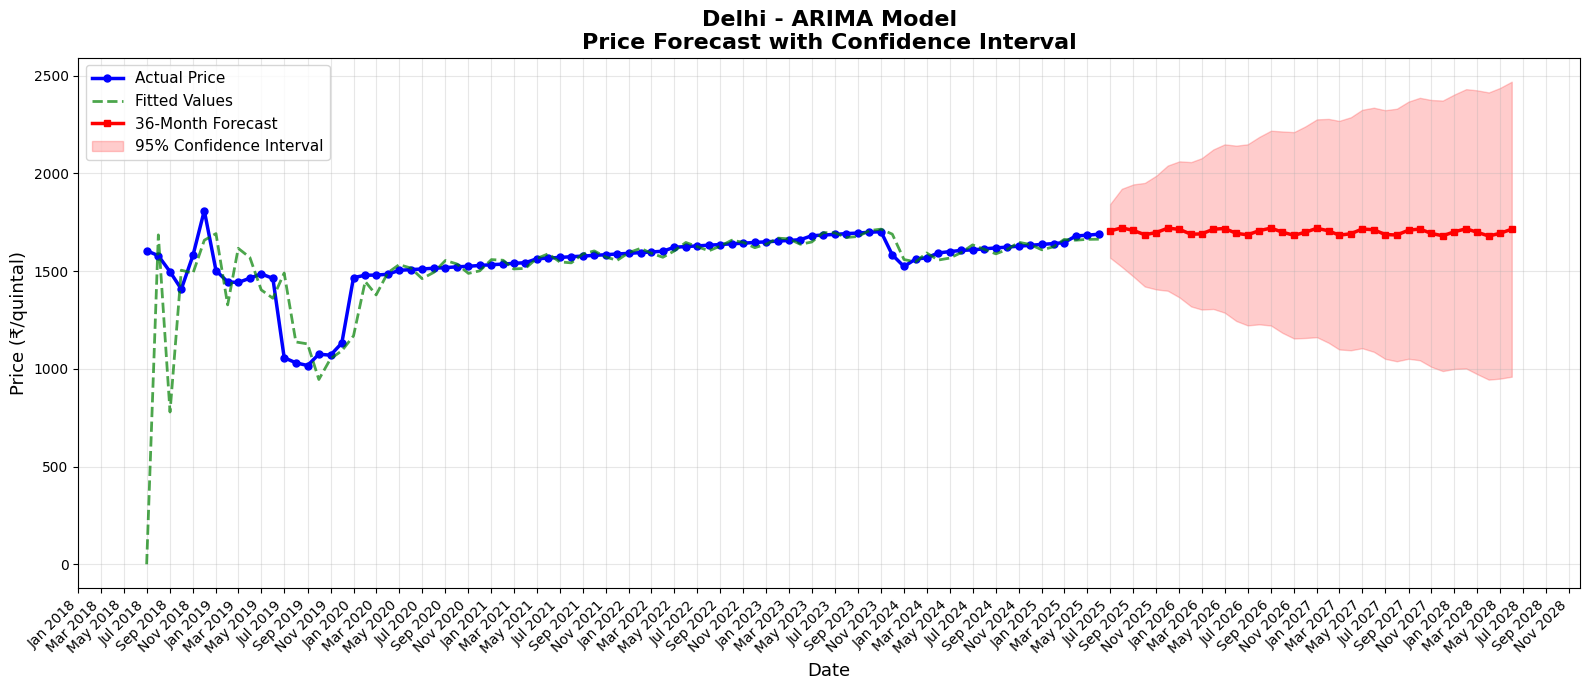


********************************************************************************
* SARIMA MODEL FOR Delhi
********************************************************************************

Delhi - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1686.33
            2 Aug 2025                      1681.23
            3 Sep 2025                      1677.61
            4 Oct 2025                      1674.96
            5 Nov 2025                      1671.67
            6 Dec 2025                      1668.70
            7 Jan 2026                      1665.30
            8 Feb 2026                      1662.37
            9 Mar 2026                      1658.99
           10 Apr 2026                      1642.75
           11 May 2026                      1639.81
           12 Jun 2026                      1636.44
           13 Jul 2026                      1636.47
           14 Aug 2026              

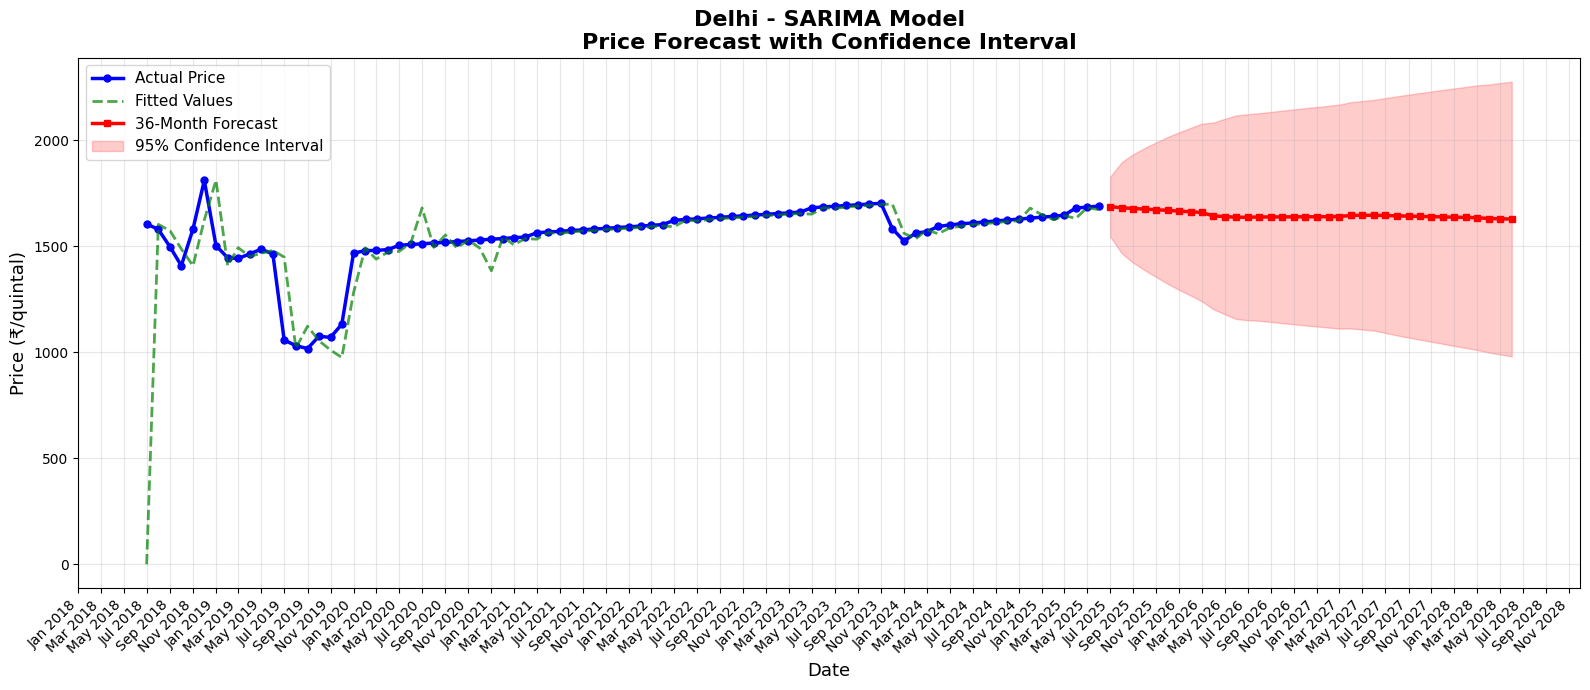


********************************************************************************
* SARIMAX MODEL FOR Delhi
********************************************************************************

Delhi - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1691.91
            2 Aug 2025                      1688.07
            3 Sep 2025                      1684.66
            4 Oct 2025                      1680.30
            5 Nov 2025                      1675.36
            6 Dec 2025                      1701.12
            7 Jan 2026                      1710.08
            8 Feb 2026                      1697.41
            9 Mar 2026                      1692.52
           10 Apr 2026                      1666.98
           11 May 2026                      1658.29
           12 Jun 2026                      1653.28
           13 Jul 2026                      1652.44
           14 Aug 2026            

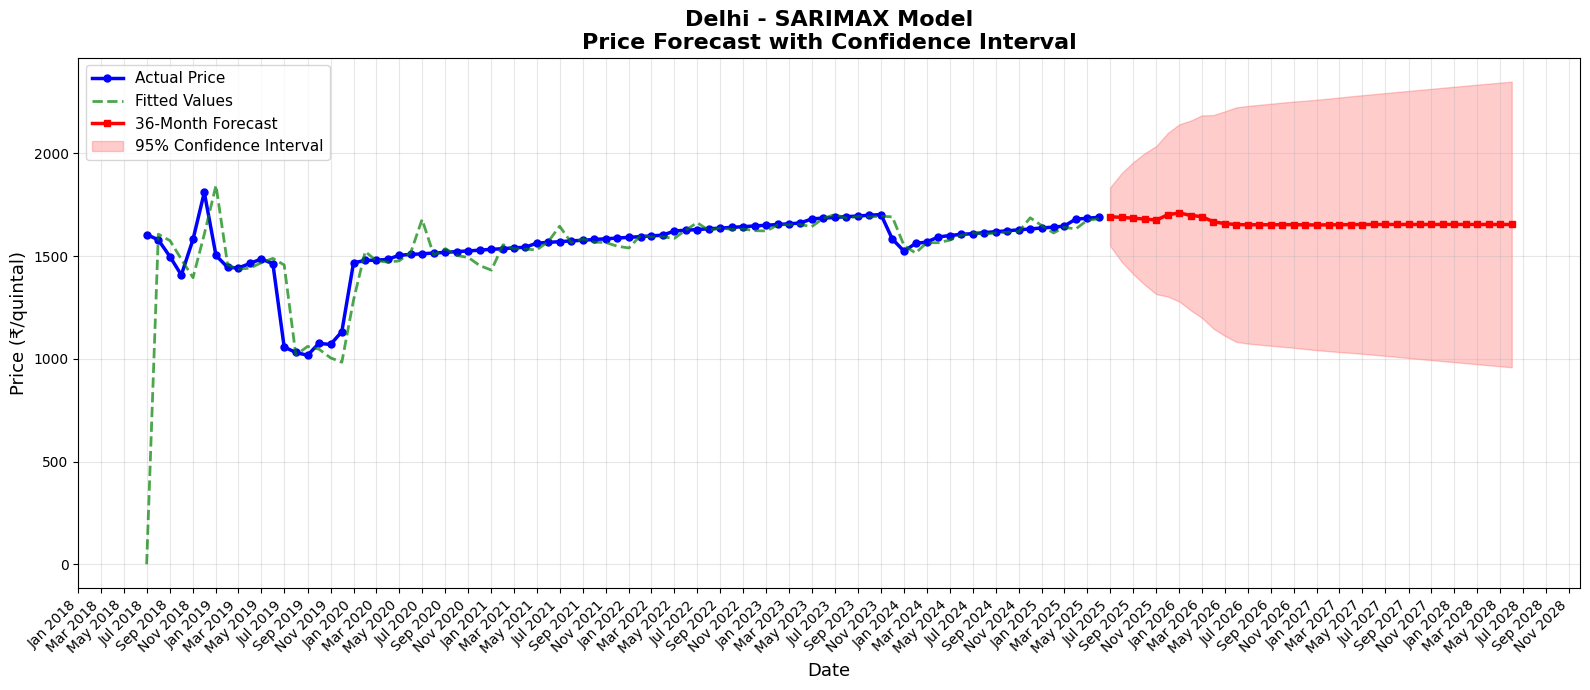



################################################################################
# GENERATING FORECASTS FOR WEST BENGAL
################################################################################


********************************************************************************
* ARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1588.63
            2 Aug 2025                      1931.40
            3 Sep 2025                      2257.80
            4 Oct 2025                      2525.09
            5 Nov 2025                      1872.11
            6 Dec 2025                      2249.70
            7 Jan 2026                      2496.76
            8 Feb 2026                      2997.98
            9 Mar 2026                      2559.07
           10 Apr 2026        

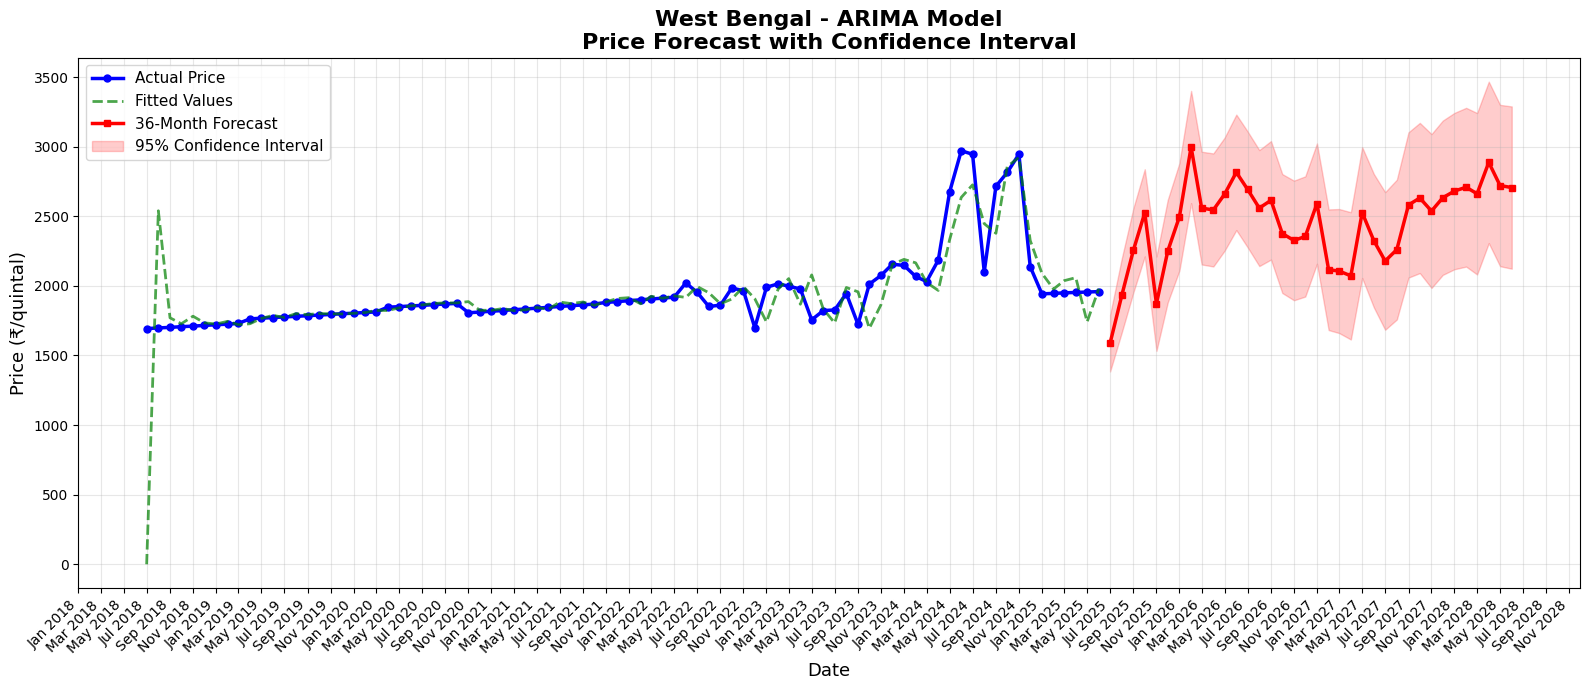


********************************************************************************
* SARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2155.79
            2 Aug 2025                      2070.22
            3 Sep 2025                      2125.14
            4 Oct 2025                      2323.92
            5 Nov 2025                      2380.95
            6 Dec 2025                      2266.30
            7 Jan 2026                      2240.52
            8 Feb 2026                      2205.97
            9 Mar 2026                      2193.44
           10 Apr 2026                      2313.97
           11 May 2026                      2681.33
           12 Jun 2026                      2898.08
           13 Jul 2026                      2914.07
           14 Aug 2026  

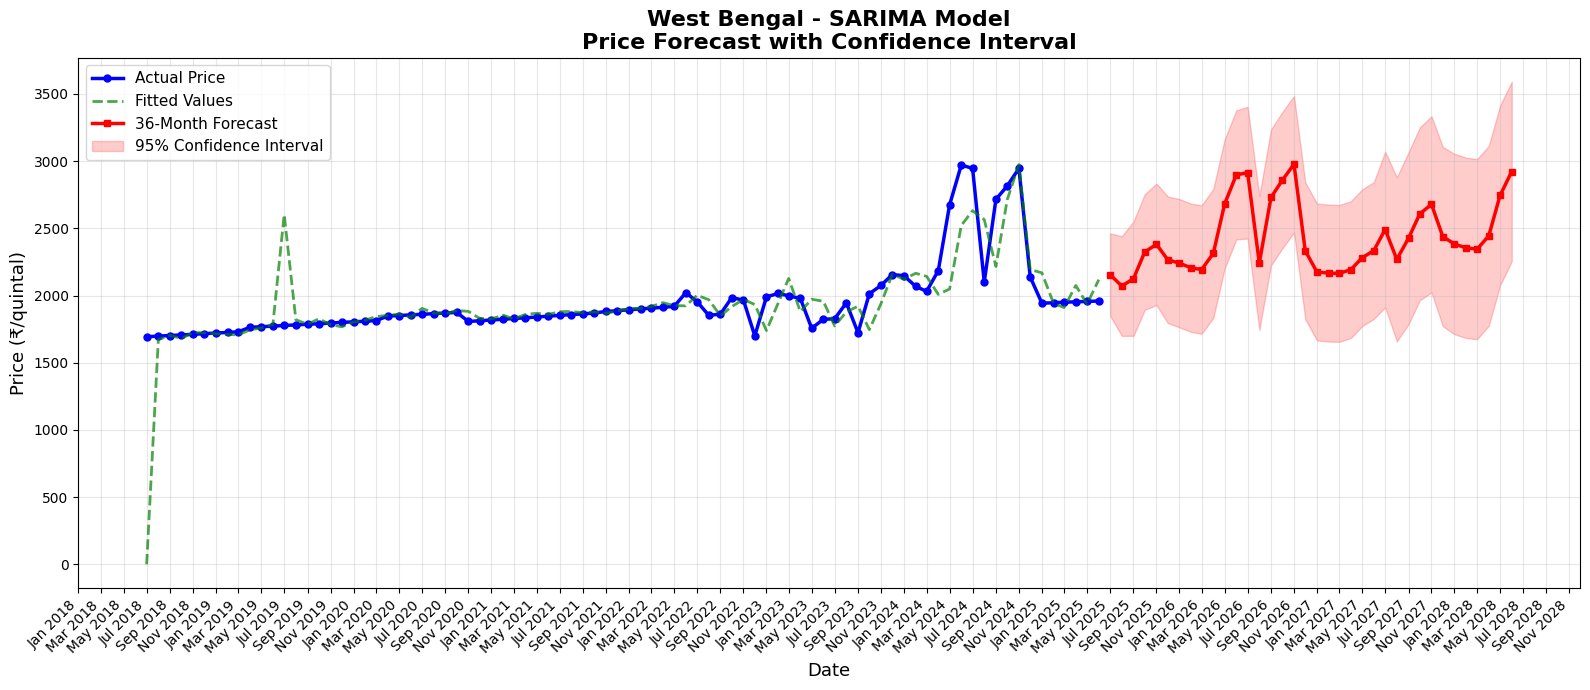


********************************************************************************
* SARIMAX MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2033.38
            2 Aug 2025                      1787.89
            3 Sep 2025                      2024.40
            4 Oct 2025                      2254.71
            5 Nov 2025                      2385.66
            6 Dec 2025                      2113.78
            7 Jan 2026                      2044.85
            8 Feb 2026                      2007.74
            9 Mar 2026                      1992.58
           10 Apr 2026                      2087.10
           11 May 2026                      2381.29
           12 Jun 2026                      2559.93
           13 Jul 2026                      2575.76
           14 Aug 2026

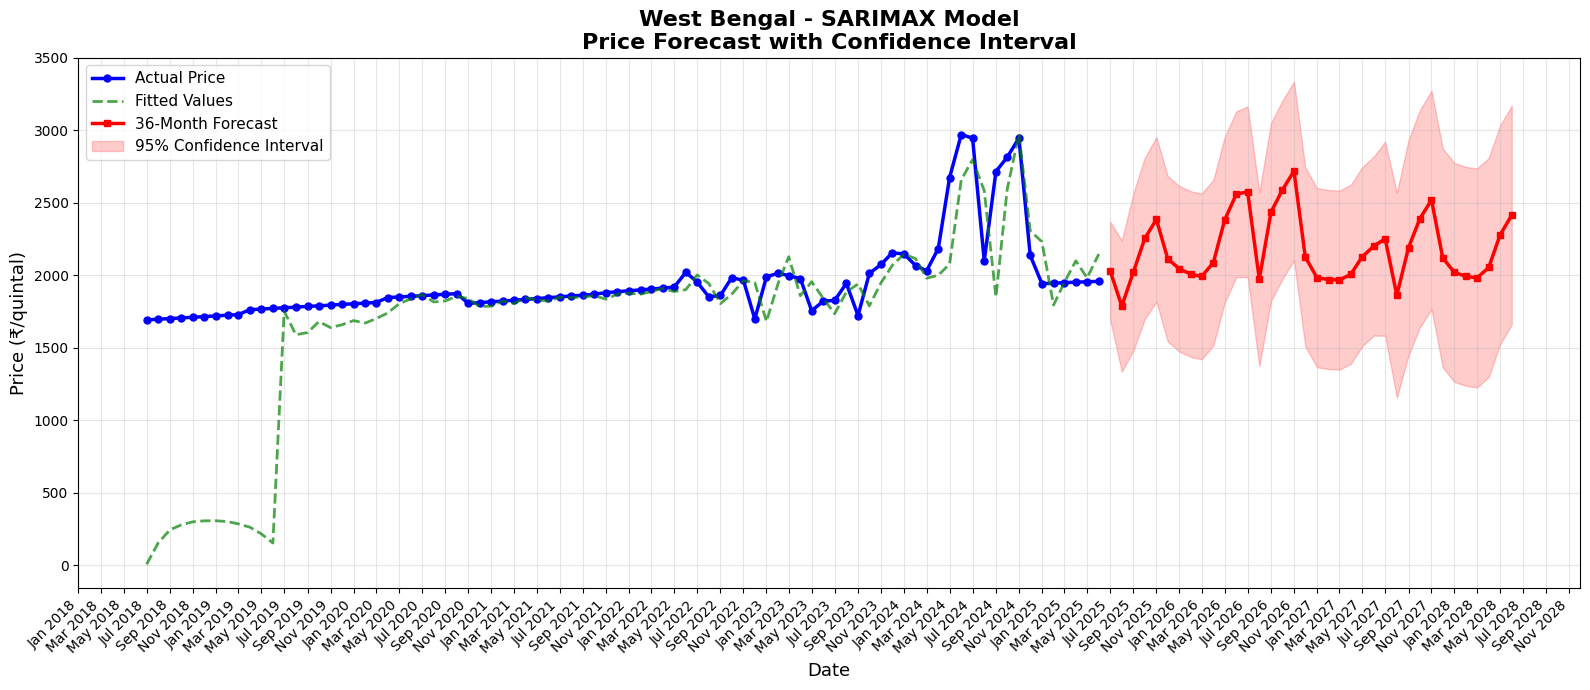



################################################################################
# GENERATING FORECASTS FOR TAMIL NADU
################################################################################


********************************************************************************
* ARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1867.66
            2 Aug 2025                      1897.18
            3 Sep 2025                      1962.66
            4 Oct 2025                      2091.50
            5 Nov 2025                      2114.10
            6 Dec 2025                      1951.78
            7 Jan 2026                      1884.06
            8 Feb 2026                      2074.47
            9 Mar 2026                      2024.04
           10 Apr 2026           

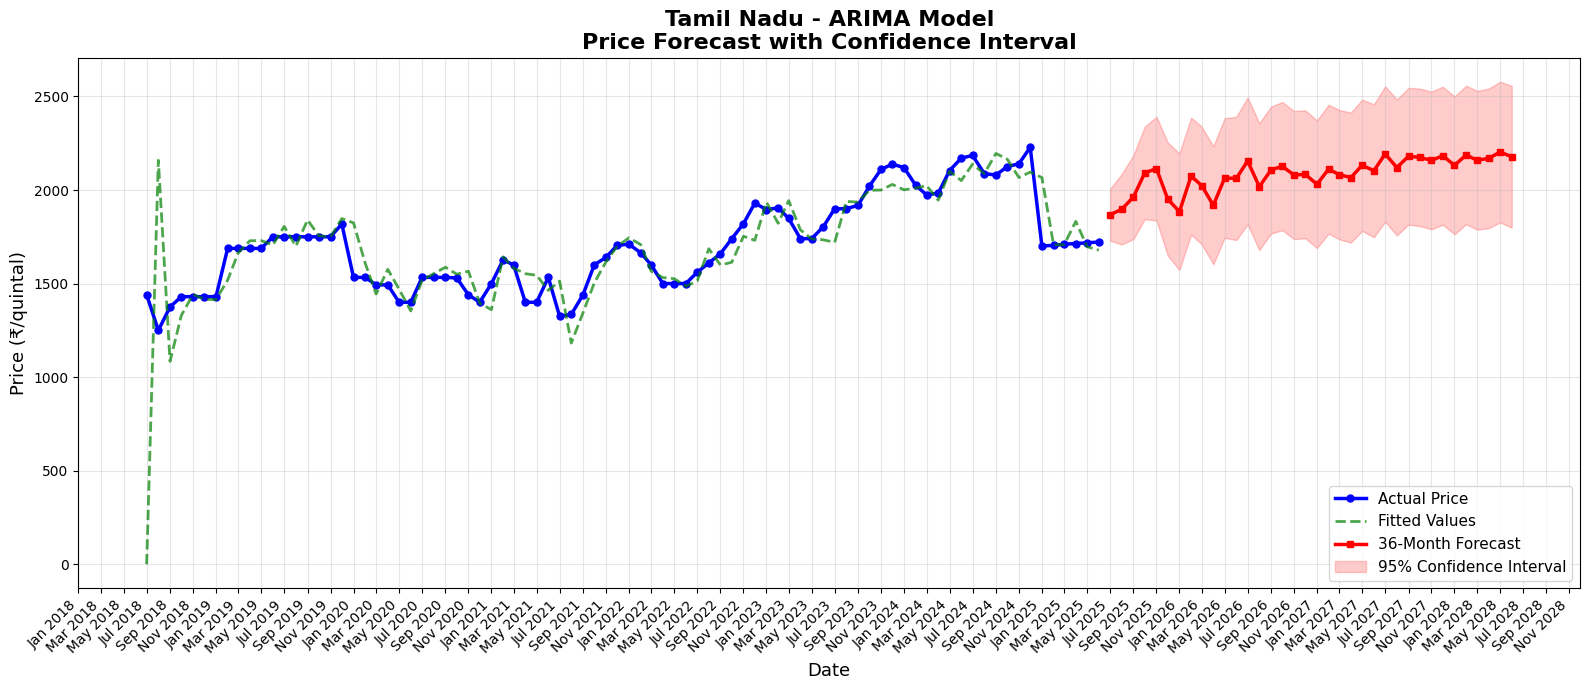


********************************************************************************
* SARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1806.78
            2 Aug 2025                      1772.71
            3 Sep 2025                      1815.49
            4 Oct 2025                      1903.80
            5 Nov 2025                      1954.72
            6 Dec 2025                      2072.93
            7 Jan 2026                      1571.17
            8 Feb 2026                      1595.32
            9 Mar 2026                      1619.01
           10 Apr 2026                      1637.83
           11 May 2026                      1654.23
           12 Jun 2026                      1668.62
           13 Jul 2026                      1762.09
           14 Aug 2026    

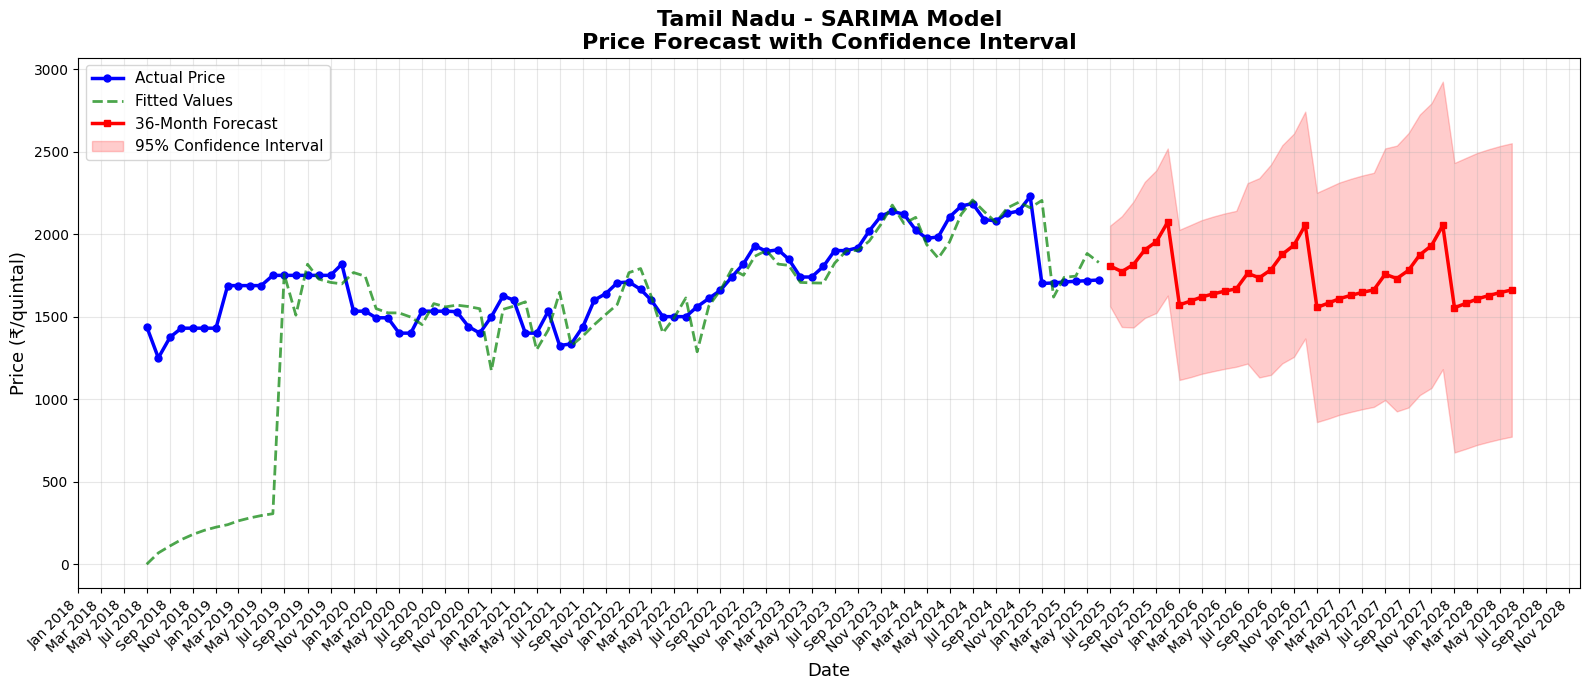


********************************************************************************
* SARIMAX MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1875.00
            2 Aug 2025                      1893.41
            3 Sep 2025                      1886.63
            4 Oct 2025                      1882.07
            5 Nov 2025                      1868.36
            6 Dec 2025                      1912.52
            7 Jan 2026                      1656.59
            8 Feb 2026                      1678.91
            9 Mar 2026                      1694.02
           10 Apr 2026                      1676.11
           11 May 2026                      1649.75
           12 Jun 2026                      1649.68
           13 Jul 2026                      1725.44
           14 Aug 2026  

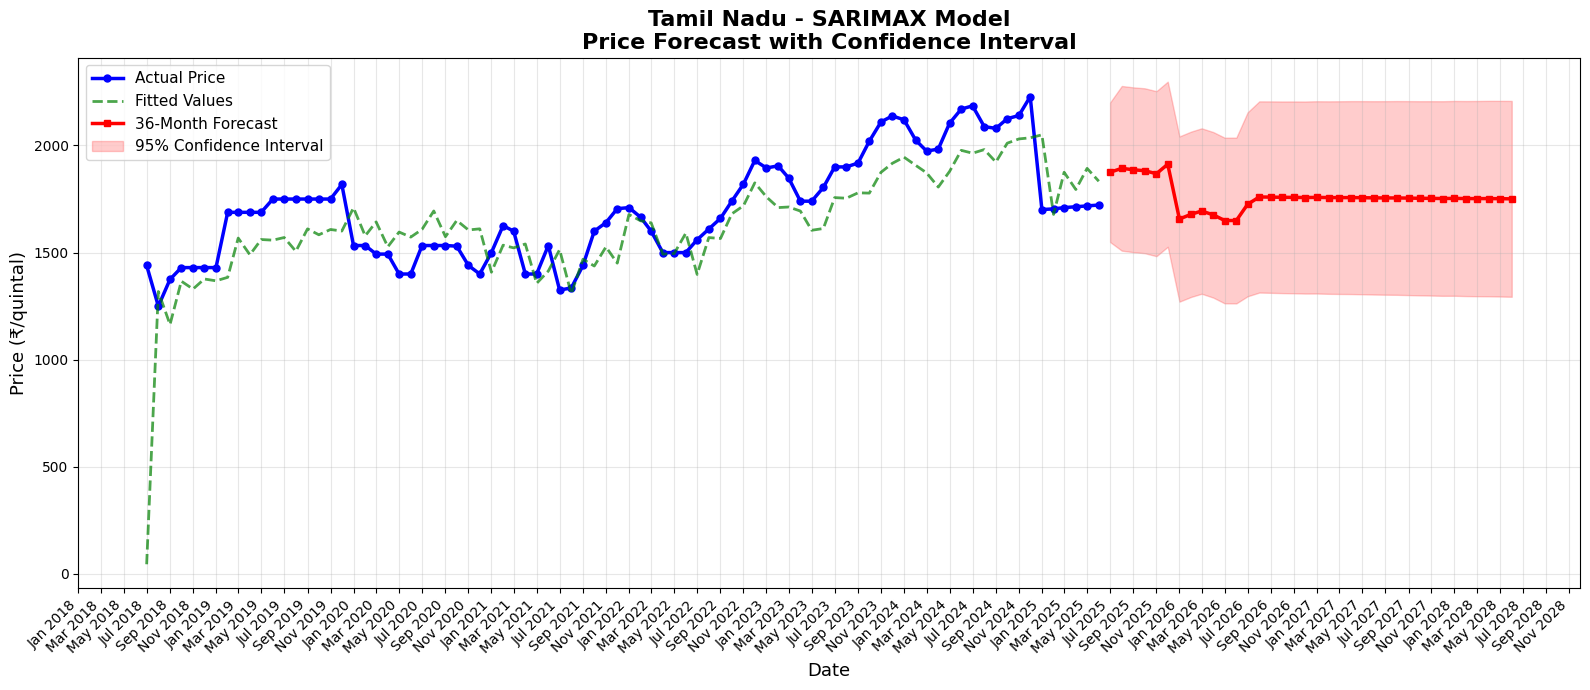



################################################################################
# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!
################################################################################



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Store the best model parameters from previous grid search
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (2, 0, 4, 2, 1, 2), 'SARIMAX': (0, 0, 3, 1, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (0, 2, 5, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (8, 1, 4), 'SARIMA': (3, 0, 0, 1, 0, 0), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (14, 2, 13), 'SARIMA': (2, 1, 5, 2, 1, 1), 'SARIMAX': (2, 0, 2, 1, 1, 0)}, # Updated SARIMAX params
    'Tamil Nadu': {'ARIMA': (9, 2, 15), 'SARIMA': (2, 0, 1, 0, 1, 0), 'SARIMAX': (1, 0, 2, 1, 0, 2)}
}

states = df['State'].unique()

def plot_forecast_with_confidence(state, model_type, best_param, price_series, production_series=None, exog_forecast=None):
    """
    Create a comprehensive forecast plot with actual, fitted, forecast, and confidence intervals
    """

    # Train model on full data
    if model_type == 'ARIMA':
        model = ARIMA(price_series, order=best_param)
        model_fit = model.fit()

        # Get fitted values
        fitted_values = model_fit.fittedvalues

        # Forecast 36 months with confidence interval
        forecast_result = model_fit.get_forecast(steps=36)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

    elif model_type == 'SARIMA':
        model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,))
        model_fit = model.fit(disp=False)

        fitted_values = model_fit.fittedvalues

        forecast_result = model_fit.get_forecast(steps=36)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

    elif model_type == 'SARIMAX' and best_param is not None:
        if production_series is None or exog_forecast is None:
            return None, None, None, None  # Skip if no exog data

        model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,), exog=production_series)
        model_fit = model.fit(disp=False)

        fitted_values = model_fit.fittedvalues

        forecast_result = model_fit.get_forecast(steps=36, exog=exog_forecast)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()
    else:
        return None, None, None, None

    # figure
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(price_series.index, price_series.values, 'b-', linewidth=2.5, label='Actual Price', marker='o', markersize=5)
    ax.plot(fitted_values.index, fitted_values.values, 'g--', linewidth=2, alpha=0.7, label='Fitted Values')
    last_date = price_series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=36, freq='MS')
    ax.plot(future_dates, forecast_mean.values, 'r-', linewidth=2.5, label='36-Month Forecast', marker='s', markersize=5)
    ax.fill_between(future_dates,
                     forecast_ci.iloc[:, 0].values,
                     forecast_ci.iloc[:, 1].values,
                     color='red', alpha=0.2, label='95% Confidence Interval')
    ax.xaxis.set_major_locator(MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # Formatting
    ax.set_title(f'{state} - {model_type} Model\nPrice Forecast with Confidence Interval', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=13)
    ax.set_ylabel('Price (₹/quintal)', fontsize=13)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    return fig, model_fit, forecast_mean, forecast_ci, future_dates

def display_predictions_table(forecast_mean, future_dates, state, model_type):
    """
    Display predictions in a formatted table
    """
    print(f"\n{'='*80}")
    print(f"{state} - {model_type} Model: 36-Month Price Forecasts")
    print(f"{'='*80}")


    forecast_df = pd.DataFrame({
        'Month': future_dates.strftime('%b %Y'),
        'Predicted Price (₹/quintal)': forecast_mean.values.round(2)
    })
    forecast_df['Month_Number'] = range(1, 37)
    forecast_df = forecast_df[['Month_Number', 'Month', 'Predicted Price (₹/quintal)']]
    print(forecast_df.to_string(index=False))
    print(f"{'='*80}\n")
    return forecast_df

# Generate plots and predictions for all states and models
plot_results = {}

for state in states:
    print(f"\n\n{'#'*80}")
    print(f"# GENERATING FORECASTS FOR {state.upper()}")
    print(f"{'#'*80}\n")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    state_plots = {}
    state_forecasts = {}

    #  ARIMA
    print(f"\n{'*'*80}")
    print(f"* ARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    arima_param = best_params[state]['ARIMA']
    result = plot_forecast_with_confidence(
        state, 'ARIMA', arima_param, price_series
    )
    if result[0] is not None:
        fig_arima, model_arima, forecast_arima, ci_arima, future_dates_arima = result

        # Display predictions table
        forecast_df_arima = display_predictions_table(forecast_arima, future_dates_arima, state, 'ARIMA')

        # Display graph
        plt.show()

        state_plots['ARIMA'] = {
            'figure': fig_arima,
            'model': model_arima,
            'forecast': forecast_arima,
            'ci': ci_arima
        }
        state_forecasts['ARIMA'] = forecast_df_arima

    # SARIMA
    print(f"\n{'*'*80}")
    print(f"* SARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    sarima_param = best_params[state]['SARIMA']
    result = plot_forecast_with_confidence(
        state, 'SARIMA', sarima_param, price_series
    )
    if result[0] is not None:
        fig_sarima, model_sarima, forecast_sarima, ci_sarima, future_dates_sarima = result

        # Display predictions table
        forecast_df_sarima = display_predictions_table(forecast_sarima, future_dates_sarima, state, 'SARIMA')

        # Display graph
        plt.show()

        state_plots['SARIMA'] = {
            'figure': fig_sarima,
            'model': model_sarima,
            'forecast': forecast_sarima,
            'ci': ci_sarima
        }
        state_forecasts['SARIMA'] = forecast_df_sarima

    #  SARIMAX
    sarimax_param = best_params[state]['SARIMAX']
    if sarimax_param is not None:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state}")
        print(f"{'*'*80}")

        if len(production_series) == len(price_series):
            exog_forecast = np.array([[production_series.values[-1]]] * 36)
            result = plot_forecast_with_confidence(
                state, 'SARIMAX', sarimax_param, price_series,
                production_series=production_series,
                exog_forecast=exog_forecast
            )
            if result[0] is not None:
                fig_sarimax, model_sarimax, forecast_sarimax, ci_sarimax, future_dates_sarimax = result

                # Display predictions table
                forecast_df_sarimax = display_predictions_table(forecast_sarimax, future_dates_sarimax, state, 'SARIMAX')

                # Display graph
                plt.show()

                state_plots['SARIMAX'] = {
                    'figure': fig_sarimax,
                    'model': model_sarimax,
                    'forecast': forecast_sarimax,
                    'ci': ci_sarimax
                }
                state_forecasts['SARIMAX'] = forecast_df_sarimax
    else:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state} - SKIPPED")
        print(f"* Reason: No production data available for this state")
        print(f"{'*'*80}")

    plot_results[state] = {
        'plots': state_plots,
        'forecasts': state_forecasts
    }

print(f"\n\n{'#'*80}")
print(f"# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!")
print(f"{'#'*80}\n")


 Identify Seasonal & External Factors

SEASONAL DECOMPOSITION ANALYSIS

Punjab:


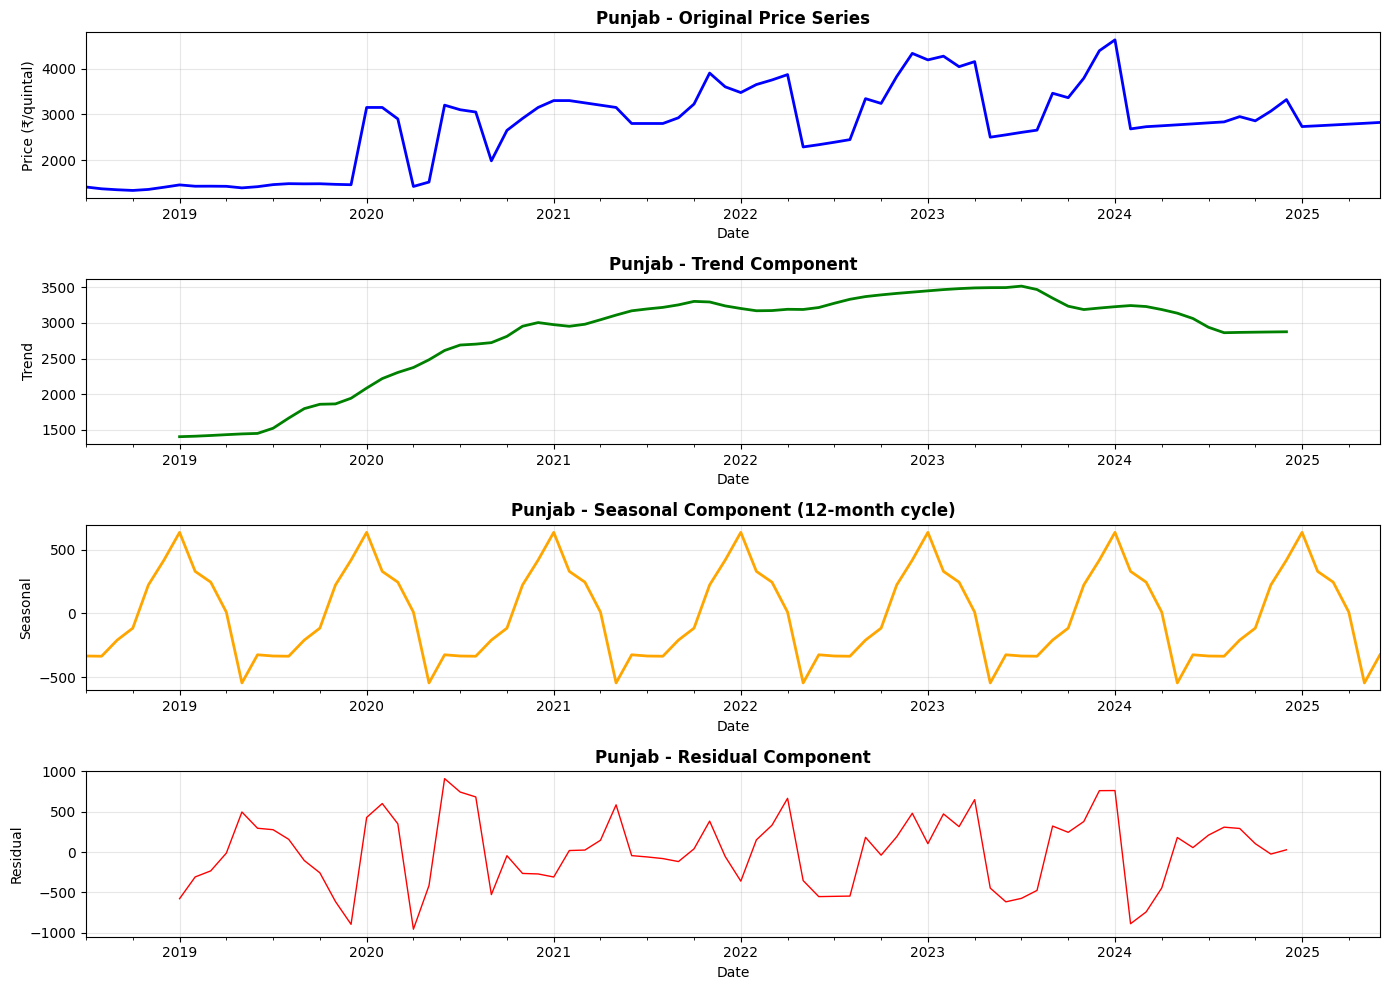

  Seasonal Strength: 0.3866
  Peak Seasonal Month: January
  Lowest Seasonal Month: May

Utar Pradesh:


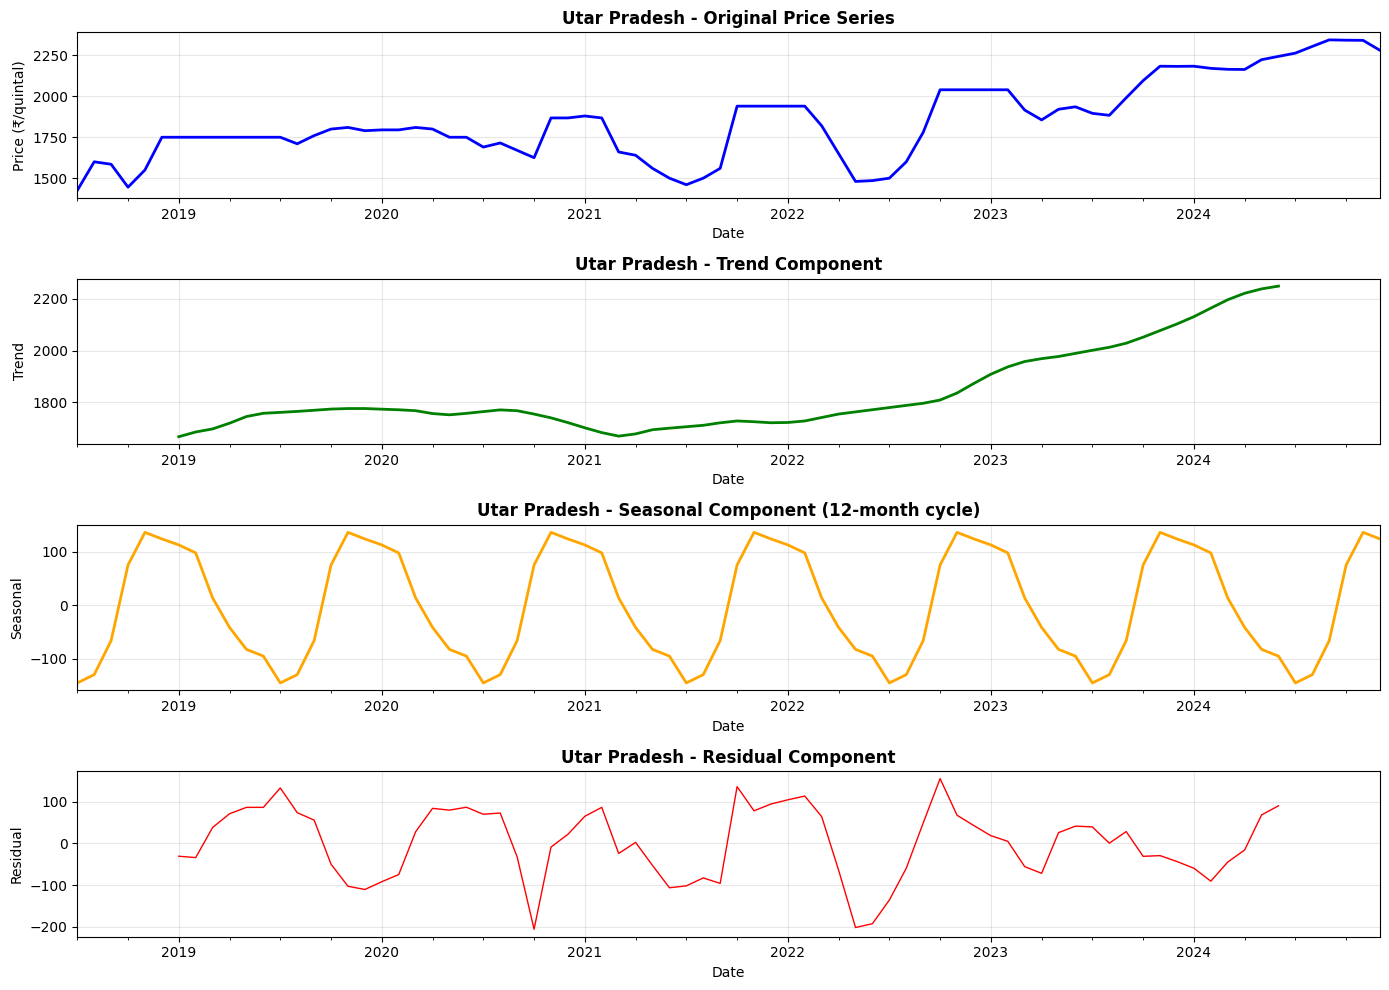

  Seasonal Strength: 0.5848
  Peak Seasonal Month: November
  Lowest Seasonal Month: July

Delhi:


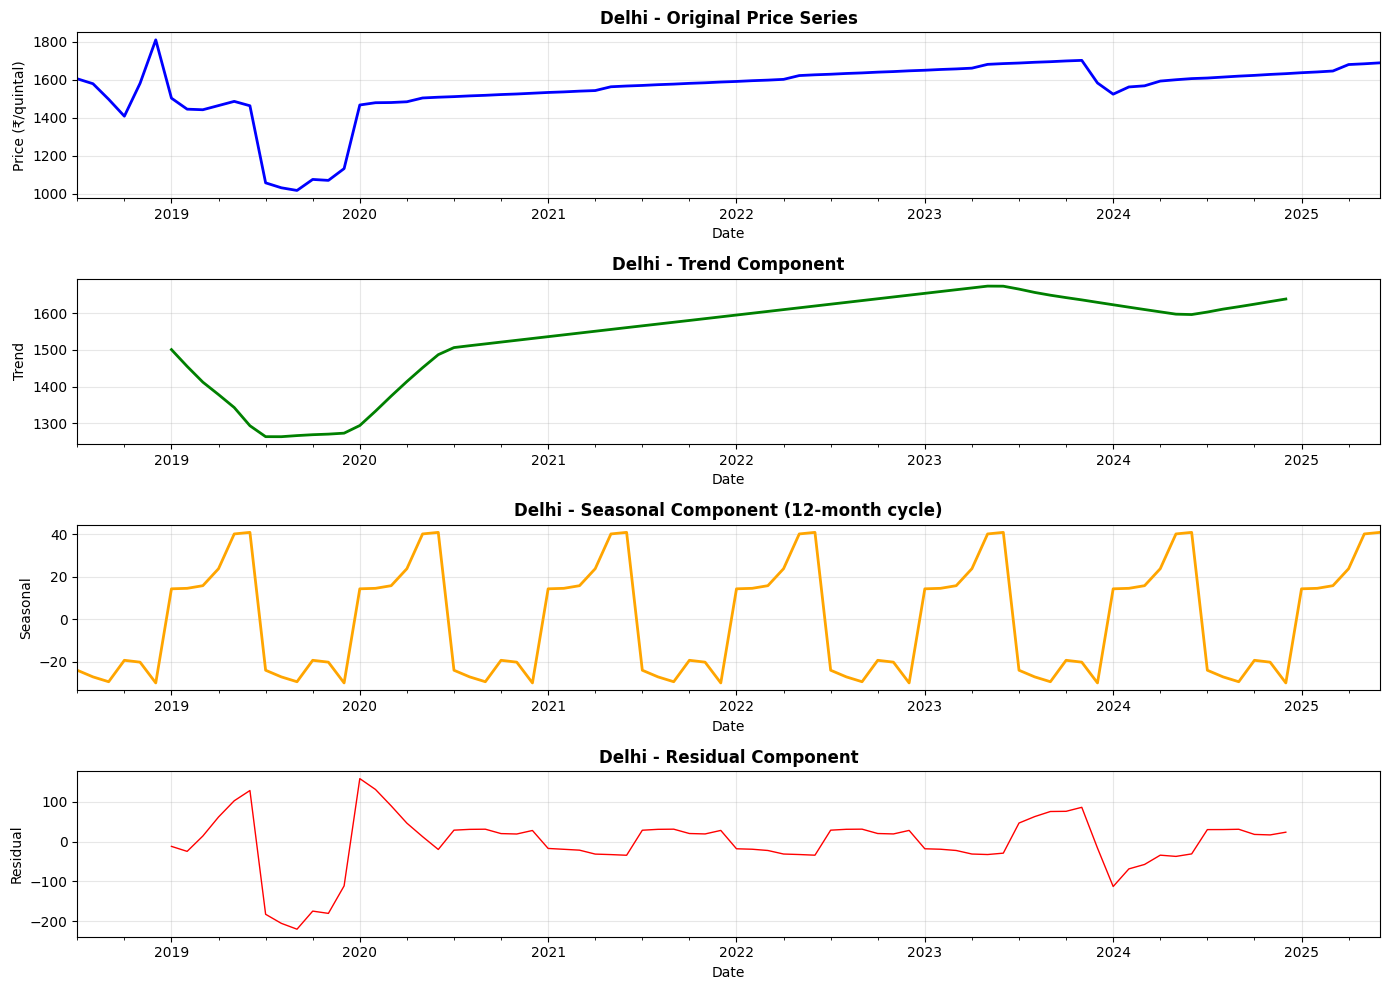

  Seasonal Strength: 0.1213
  Peak Seasonal Month: June
  Lowest Seasonal Month: December

West Bengal:


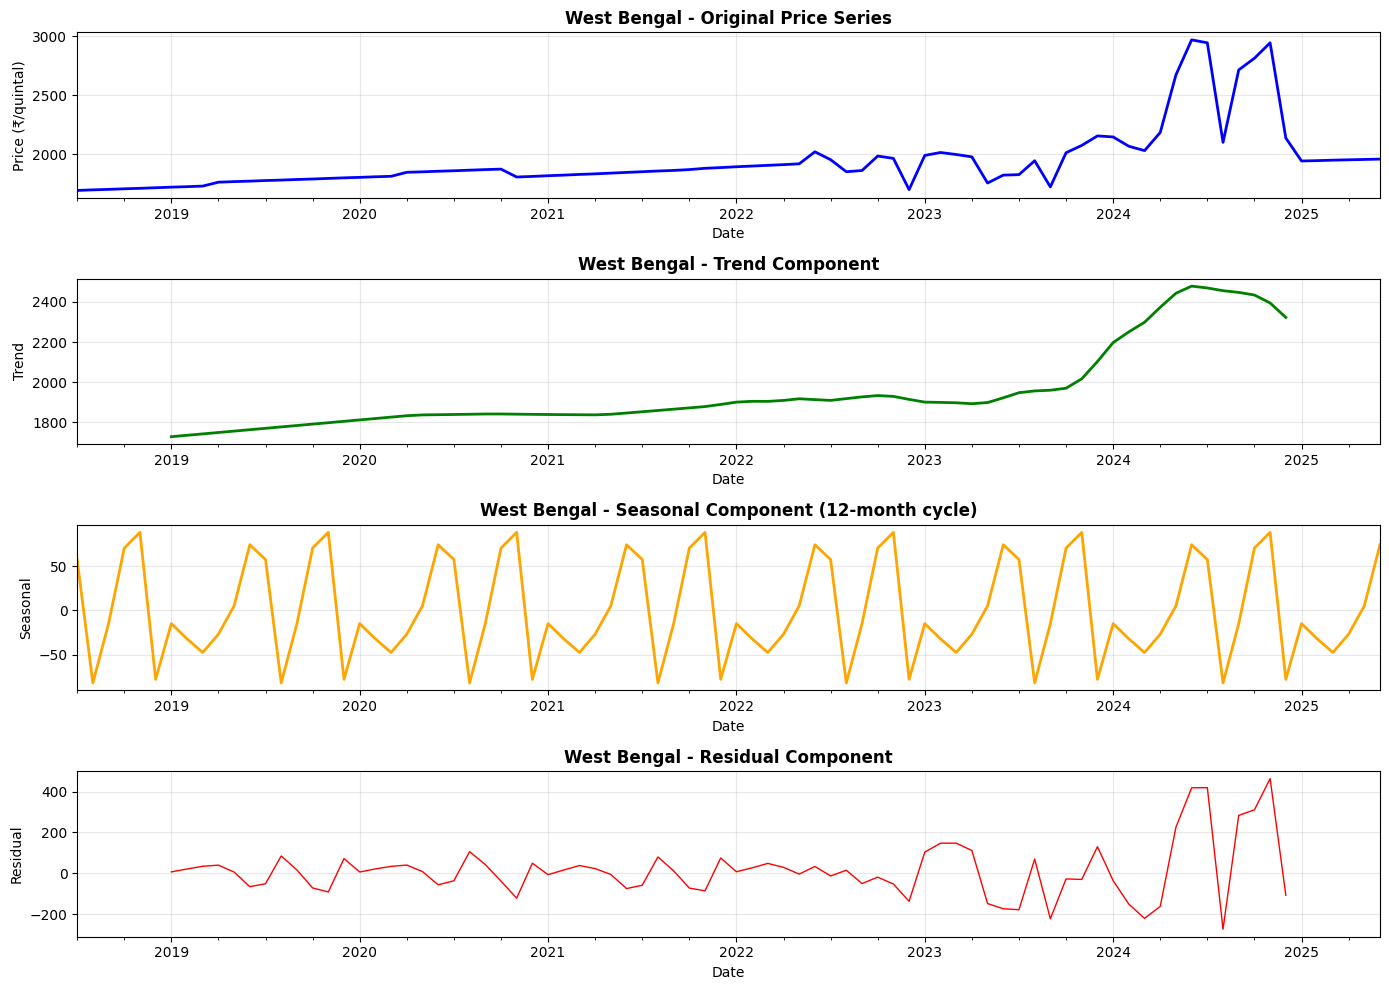

  Seasonal Strength: 0.1478
  Peak Seasonal Month: November
  Lowest Seasonal Month: August

Tamil Nadu:


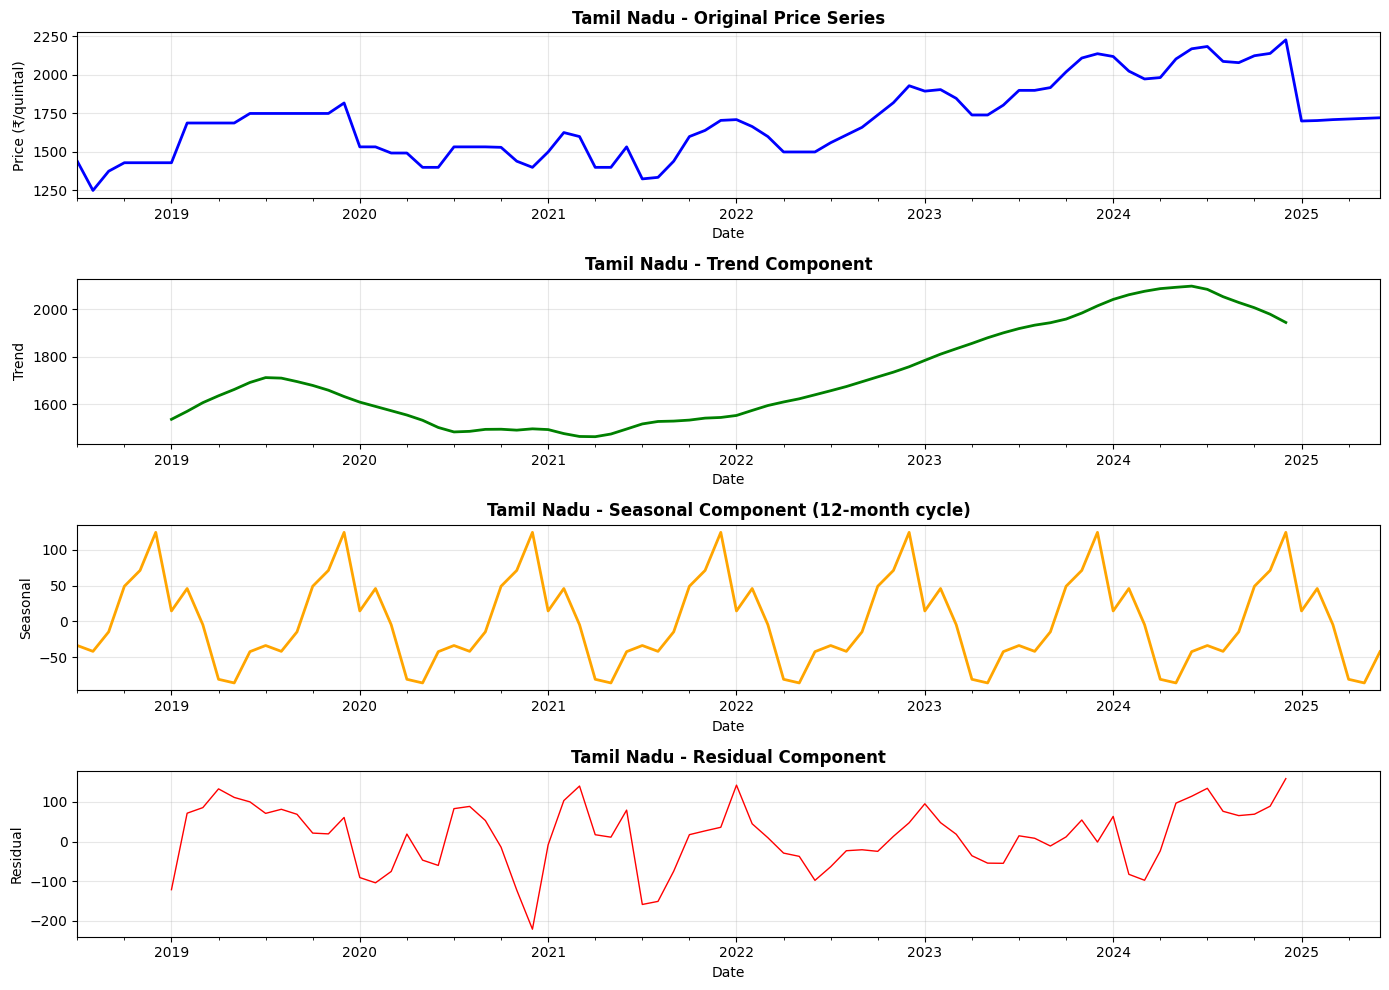

  Seasonal Strength: 0.3677
  Peak Seasonal Month: December
  Lowest Seasonal Month: May

MONTHLY SEASONAL PATTERNS

Punjab:
 Month Month_Name        mean         std    min    max
     1    January 3275.857143 1024.719706 1460.0 4625.0
     2   February 3033.142857  890.978568 1431.0 4269.0
     3      March 2981.428571  846.515772 1432.0 4040.0
     4      April 2801.142857 1071.695919 1426.0 4150.0
     5        May 2347.285714  664.273968 1395.0 3150.0
     6       June 2560.714286  568.228743 1421.0 3200.0
     7       July 2370.142857  671.096721 1414.0 3100.0
     8     August 2378.571429  673.304502 1375.0 3050.0
     9  September 2499.857143  878.115298 1354.0 3460.0
    10    October 2594.000000  844.787547 1339.0 3363.0
    11   November 2903.714286 1086.337688 1361.0 3900.0
    12   December 3094.571429 1225.354079 1409.0 4388.0


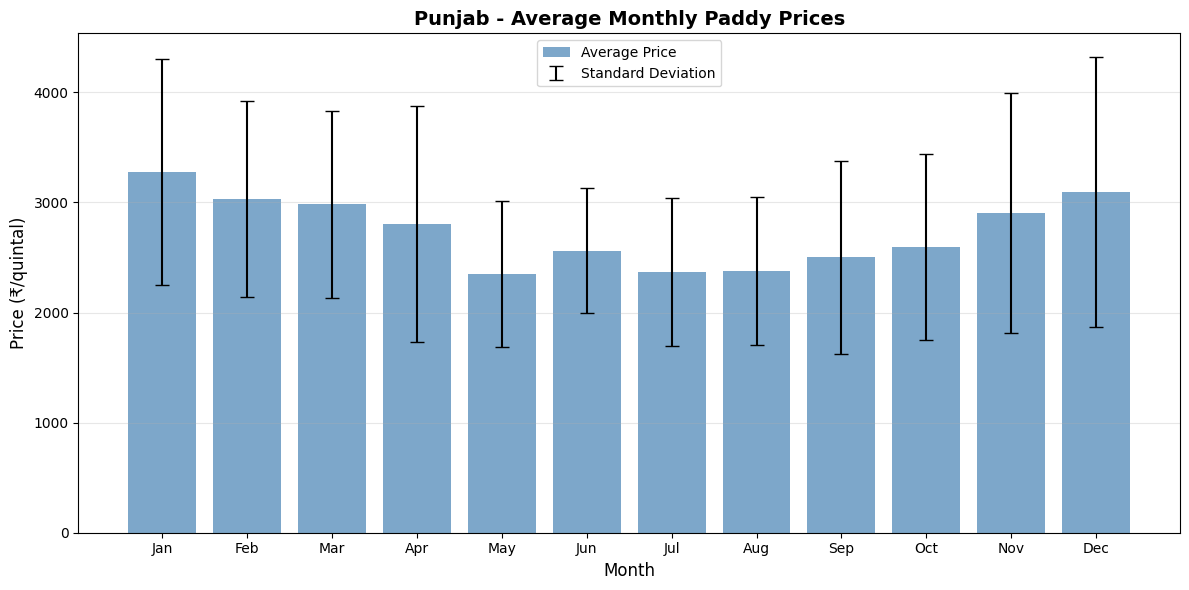


Utar Pradesh:
 Month Month_Name        mean        std    min    max
     1    January 1931.500000 161.138139 1750.0 2184.0
     2   February 1927.333333 157.928676 1750.0 2171.0
     3      March 1853.500000 174.417602 1660.0 2165.0
     4      April 1810.000000 192.682122 1640.0 2164.0
     5        May 1780.833333 267.287423 1480.0 2224.0
     6       June 1777.500000 285.243580 1485.0 2244.0
     7       July 1712.142857 297.574881 1425.0 2264.0
     8     August 1759.142857 269.481248 1500.0 2305.0
     9  September 1813.000000 275.393052 1560.0 2345.0
    10    October 1898.428571 302.351262 1445.0 2343.0
    11   November 1962.000000 258.822977 1550.0 2342.0
    12   December 1978.857143 199.392769 1750.0 2281.0


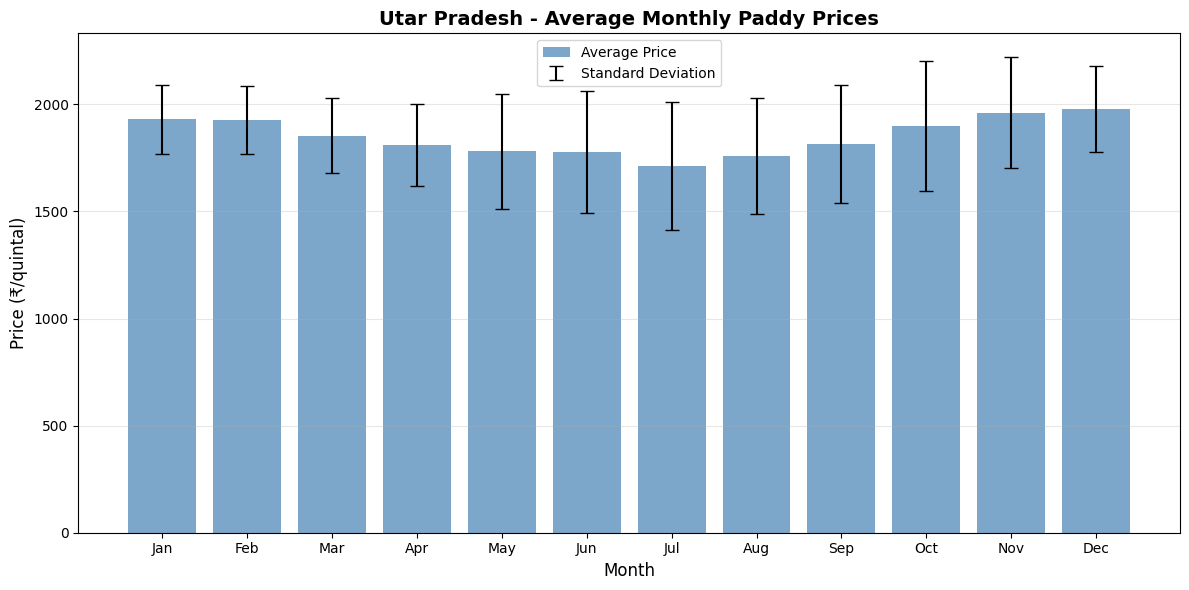


Delhi:
 Month Month_Name        mean        std    min    max
     1    January 1557.857143  69.379220 1467.0 1650.0
     2   February 1558.857143  78.505687 1445.0 1654.0
     3      March 1561.571429  80.642952 1442.0 1657.0
     4      April 1575.285714  82.764151 1464.0 1680.0
     5        May 1591.428571  78.705902 1486.0 1684.0
     6       June 1592.000000  85.373688 1463.0 1689.0
     7       July 1524.142857 212.947903 1057.0 1688.0
     8     August 1519.714286 222.385337 1031.0 1692.0
     9  September 1508.428571 227.206116 1017.0 1695.0
    10    October 1506.857143 212.185005 1075.0 1699.0
    11   November 1533.285714 211.748053 1070.0 1702.0
    12   December 1560.142857 208.450976 1132.0 1810.0


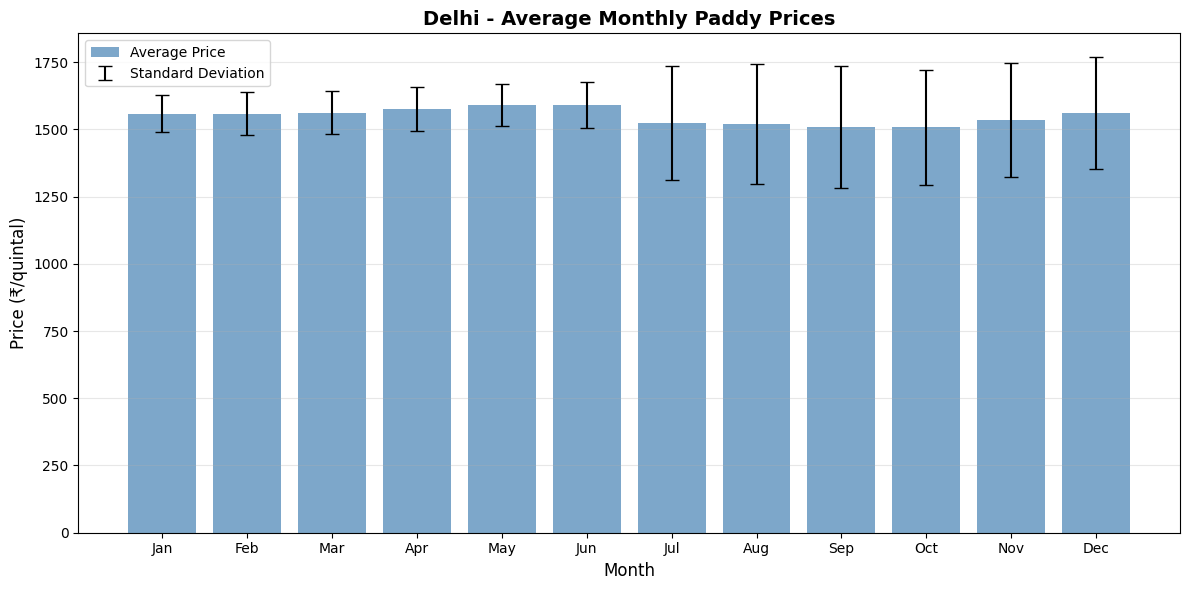


West Bengal:
 Month Month_Name        mean        std    min    max
     1    January 1902.428571 140.791639 1721.0 2147.0
     2   February 1898.000000 121.361718 1725.0 2068.0
     3      March 1893.857143 108.433434 1730.0 2031.0
     4      April 1924.571429 136.607537 1763.0 2185.0
     5        May 1966.285714 320.410525 1756.0 2674.0
     6       June 2035.428571 421.098111 1772.0 2971.0
     7       July 1987.000000 430.360314 1693.0 2946.0
     8     August 1871.428571 127.128357 1698.0 2101.0
     9  September 1931.714286 352.622893 1702.0 2716.0
    10    October 2007.714286 371.242829 1707.0 2815.0
    11   November 2025.714286 423.102318 1711.0 2946.0
    12   December 1887.000000 188.310913 1700.0 2156.0


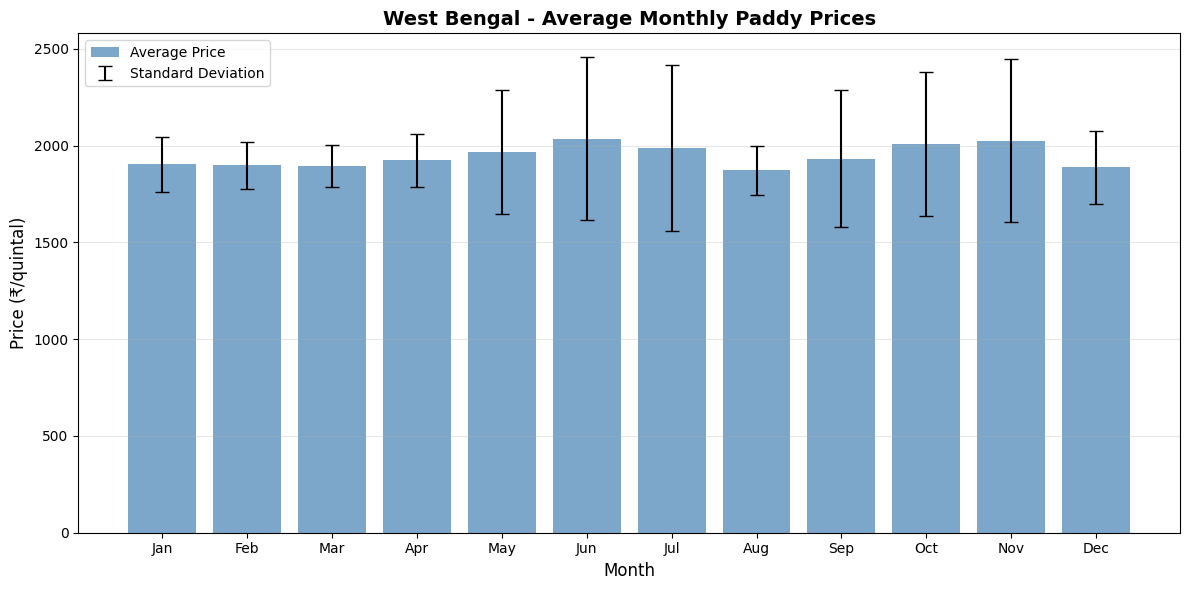


Tamil Nadu:
 Month Month_Name        mean        std    min    max
     1    January 1698.428571 243.343966 1430.0 2120.0
     2   February 1735.142857 170.173861 1533.0 2025.0
     3      March 1701.857143 163.324247 1493.0 1974.0
     4      April 1645.428571 197.497559 1400.0 1983.0
     5        May 1650.000000 247.582983 1400.0 2104.0
     6       June 1697.000000 255.775292 1400.0 2170.0
     7       July 1670.428571 296.456212 1325.0 2185.0
     8     August 1638.000000 299.402182 1250.0 2088.0
     9  September 1679.428571 256.312217 1375.0 2080.0
    10    October 1742.142857 253.802041 1430.0 2125.0
    11   November 1761.428571 287.600914 1430.0 2140.0
    12   December 1807.000000 321.515681 1400.0 2228.0


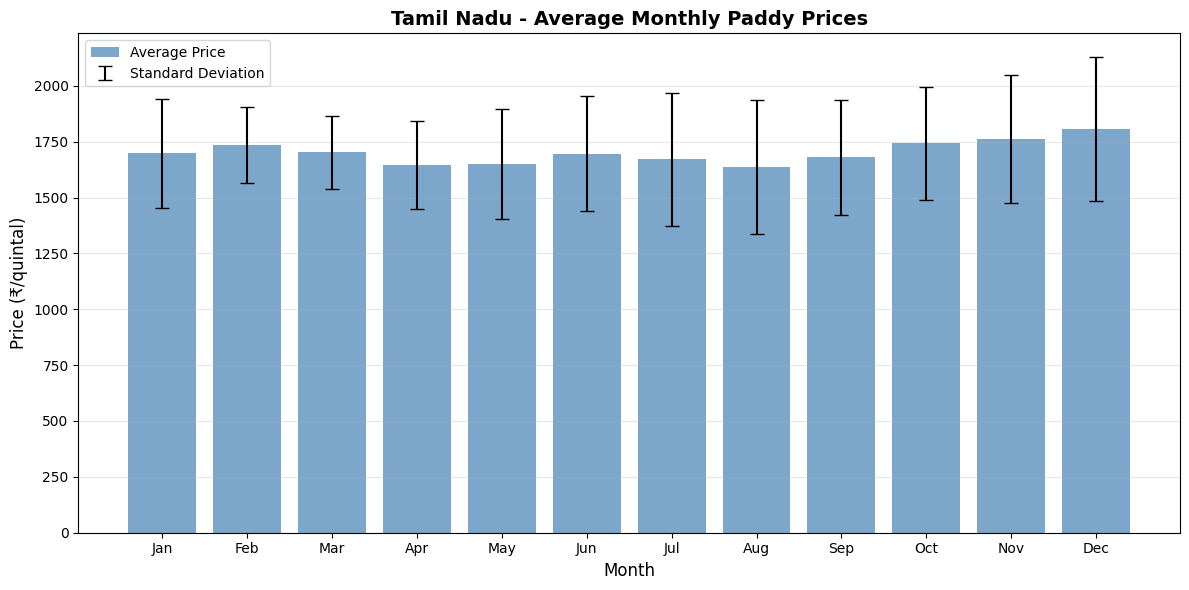


EXTERNAL FACTORS INFLUENCING PADDY PRICES

Seasonal Factors:
  1. Kharif Season (Jun-Sep): Primary planting season; supply increases post-harvest (Oct-Nov)
  2. Rabi Season (Oct-Mar): Secondary cultivation; prices often higher due to lower supply
  3. Summer Season (Mar-May): Lowest production; prices peak
  4. Monsoon (Jun-Sep): Affects crop yields and quality
  5. Harvest Period (Oct-Nov for Kharif, Mar-Apr for Rabi): Price drops due to increased supply

Government Policies:
  1. Minimum Support Price (MSP): Announced annually; affects farmer selling prices
  2. Agricultural subsidies and procurement policies
  3. Trade restrictions and export/import duties
  4. Food security stock management

Market Factors:
  1. Global commodity prices and international rice demand
  2. Storage costs and warehouse capacity
  3. Transport and logistics costs
  4. Competition from other grains (wheat, maize)

Environmental Factors:
  1. Rainfall patterns affecting crop yield
  2. Drought or floods c

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# SEASONAL DECOMPOSITION
print("="*80)
print("SEASONAL DECOMPOSITION ANALYSIS")
print("="*80)

states = df['State'].unique()

for state in states:
    print(f"\n{state}:")
    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()

    if len(price_series) >= 24:
        try:

            decomposition = seasonal_decompose(price_series, model='additive', period=12)
            trend = decomposition.trend
            seasonal = decomposition.seasonal
            residual = decomposition.resid

            fig, axes = plt.subplots(4, 1, figsize=(14, 10))

            price_series.plot(ax=axes[0], color='blue', linewidth=2)
            axes[0].set_ylabel('Price (₹/quintal)')
            axes[0].set_title(f'{state} - Original Price Series', fontweight='bold')
            axes[0].grid(True, alpha=0.3)

            trend.plot(ax=axes[1], color='green', linewidth=2)
            axes[1].set_ylabel('Trend')
            axes[1].set_title(f'{state} - Trend Component', fontweight='bold')
            axes[1].grid(True, alpha=0.3)

            seasonal.plot(ax=axes[2], color='orange', linewidth=2)
            axes[2].set_ylabel('Seasonal')
            axes[2].set_title(f'{state} - Seasonal Component (12-month cycle)', fontweight='bold')
            axes[2].grid(True, alpha=0.3)

            residual.plot(ax=axes[3], color='red', linewidth=1)
            axes[3].set_ylabel('Residual')
            axes[3].set_title(f'{state} - Residual Component', fontweight='bold')
            axes[3].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Calculate seasonal strength
            seasonal_strength = 1 - (np.var(residual, ddof=1) / np.var(seasonal + residual, ddof=1))
            print(f"  Seasonal Strength: {seasonal_strength:.4f}")
            print(f"  Peak Seasonal Month: {seasonal.idxmax().strftime('%B')}")
            print(f"  Lowest Seasonal Month: {seasonal.idxmin().strftime('%B')}")

        except Exception as e:
            print(f"  Could not perform decomposition: {e}")

# MONTHLY SEASONAL PATTERN
print("\n" + "="*80)
print("MONTHLY SEASONAL PATTERNS")
print("="*80)

for state in states:
    state_df = df[df['State'] == state].copy()
    state_df['Month'] = state_df['Date'].dt.month
    state_df['Month_Name'] = state_df['Date'].dt.strftime('%B')

    monthly_avg = state_df.groupby(['Month', 'Month_Name'])['Prices'].agg(['mean', 'std', 'min', 'max']).reset_index()
    monthly_avg = monthly_avg.sort_values('Month')

    print(f"\n{state}:")
    print(monthly_avg.to_string(index=False))

    # Visualize monthly patterns
    fig, ax = plt.subplots(figsize=(12, 6))
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.bar(months, monthly_avg['mean'].values, color='steelblue', alpha=0.7, label='Average Price')
    ax.errorbar(months, monthly_avg['mean'].values, yerr=monthly_avg['std'].values,
                fmt='none', color='black', capsize=5, label='Standard Deviation')

    ax.set_title(f'{state} - Average Monthly Paddy Prices', fontsize=14, fontweight='bold')
    ax.set_ylabel('Price (₹/quintal)', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# EXTERNAL FACTORS RESEARCH
print("\n" + "="*80)
print("EXTERNAL FACTORS INFLUENCING PADDY PRICES")
print("="*80)

external_factors = {
    'Seasonal Factors': [
        'Kharif Season (Jun-Sep): Primary planting season; supply increases post-harvest (Oct-Nov)',
        'Rabi Season (Oct-Mar): Secondary cultivation; prices often higher due to lower supply',
        'Summer Season (Mar-May): Lowest production; prices peak',
        'Monsoon (Jun-Sep): Affects crop yields and quality',
        'Harvest Period (Oct-Nov for Kharif, Mar-Apr for Rabi): Price drops due to increased supply'
    ],
    'Government Policies': [
        'Minimum Support Price (MSP): Announced annually; affects farmer selling prices',
        'Agricultural subsidies and procurement policies',
        'Trade restrictions and export/import duties',
        'Food security stock management'
    ],
    'Market Factors': [
        'Global commodity prices and international rice demand',
        'Storage costs and warehouse capacity',
        'Transport and logistics costs',
        'Competition from other grains (wheat, maize)'
    ],
    'Environmental Factors': [
        'Rainfall patterns affecting crop yield',
        'Drought or floods causing crop damage',
        'Pest infestations',
        'Soil quality and fertilizer availability'
    ],
    'Economic Factors': [
        'Inflation and currency exchange rates',
        'Purchasing power of consumers',
        'Rural wages and farm income',
        'Credit availability for farmers'
    ]
}

for category, factors in external_factors.items():
    print(f"\n{category}:")
    for i, factor in enumerate(factors, 1):
        print(f"  {i}. {factor}")


 Actionable Insights for Stakeholders

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Store best model parameters
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (2, 0, 4, 2, 1, 2), 'SARIMAX': (0, 0, 3, 1, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (0, 2, 5, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (8, 1, 4), 'SARIMA': (3, 0, 0, 1, 0, 0), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (14, 2, 13), 'SARIMA': (2, 1, 5, 2, 1, 1), 'SARIMAX': (2, 0, 2, 1, 1, 0)}, # Updated SARIMAX params
    'Tamil Nadu': {'ARIMA': (9, 2, 15), 'SARIMA': (2, 0, 1, 0, 1, 0), 'SARIMAX': (1, 0, 2, 1, 0, 2)}
}

print("="*100)
print("ACTIONABLE INSIGHTS FOR PADDY STAKEHOLDERS - 36 MONTH FORECAST ANALYSIS")
print("="*100)

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')

states = df['State'].unique()

for state in states:
    print(f"\n\n{'#'*100}")
    print(f"# {state.upper()} - STAKEHOLDER INSIGHTS")
    print(f"{'#'*100}\n")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'

    # Get best SARIMA model (captures seasonality well)
    sarima_param = best_params[state]['SARIMA']
    model = SARIMAX(price_series, order=sarima_param[:3], seasonal_order=sarima_param[3:] + (12,))
    model_fit = model.fit(disp=False)

    # Get forecasts
    forecast_result = model_fit.get_forecast(steps=36)
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()

    # Calculate statistics
    current_price = price_series.iloc[-1]
    avg_forecast = forecast_mean.mean()
    min_forecast = forecast_mean.min()
    max_forecast = forecast_mean.max()
    forecast_trend = (forecast_mean.iloc[-1] - forecast_mean.iloc[0]) / forecast_mean.iloc[0] * 100

    # Identify peak and low months
    peak_month_idx = forecast_mean.idxmax()
    low_month_idx = forecast_mean.idxmin()

    print(f"Current Price: ₹{current_price:.2f} per quintal")
    print(f"Average Forecasted Price (36 months): ₹{avg_forecast:.2f} per quintal")
    print(f"Forecasted Price Range: ₹{min_forecast:.2f} - ₹{max_forecast:.2f}")
    print(f"Overall Trend (36-month): {forecast_trend:+.2f}%")
    print(f"Expected Peak Month: {peak_month_idx.strftime('%B %Y')} (₹{forecast_mean.max():.2f})")
    print(f"Expected Low Month: {low_month_idx.strftime('%B %Y')} (₹{forecast_mean.min():.2f})")

    # FARMERS INSIGHTS
    print(f"\n{'─'*100}")
    print("INSIGHTS FOR FARMERS")
    print(f"{'─'*100}")

    if forecast_trend > 5:
        print(f"✓ Price Outlook: POSITIVE - Prices expected to rise by {abs(forecast_trend):.1f}% over next 3 years")
        print(f"  Recommendation: Consider increasing production or holding stock for better prices")
    elif forecast_trend < -5:
        print(f"✗ Price Outlook: NEGATIVE - Prices expected to fall by {abs(forecast_trend):.1f}% over next 3 years")
        print(f"  Recommendation: Focus on cost reduction and higher yields to maintain profitability")
    else:
        print(f"→ Price Outlook: STABLE - Prices expected to remain relatively stable")
        print(f"  Recommendation: Focus on yield optimization and quality improvement")

    print(f"\n• Best Selling Period: {peak_month_idx.strftime('%B %Y')} onwards")
    print(f"  - Expected to get ₹{forecast_mean.max():.2f}/quintal (premium of ₹{(forecast_mean.max()-avg_forecast):.2f})")
    print(f"  - Recommended Action: Plan harvest to coincide with peak season for better returns")

    print(f"\n• Avoid Selling Period: {low_month_idx.strftime('%B %Y')} onwards")
    print(f"  - Expected price drop to ₹{forecast_mean.min():.2f}/quintal")
    print(f"  - Recommended Action: Hold stock or use government procurement schemes (MSP)")

    print(f"\n• Seasonal Advice:")
    print(f"  - Kharif Harvest (Oct-Nov): Prices typically lower; consider bulk storage")
    print(f"  - Rabi Harvest (Mar-Apr): Generally higher prices due to lower supply")
    print(f"  - May-Jun: Historically highest prices; prioritize sales during this period if possible")

    # TRADERS INSIGHTS
    print(f"\n{'─'*100}")
    print("INSIGHTS FOR TRADERS & AGRI-BUSINESSES")
    print(f"{'─'*100}")

    price_volatility = forecast_ci.iloc[:, 1].mean() - forecast_ci.iloc[:, 0].mean()
    print(f"\n• Price Volatility (next 36 months): ₹{price_volatility/2:.2f} (±95% CI)")

    if price_volatility > 200:
        print(f"  Risk Level: HIGH - Significant price swings expected")
        print(f"  Strategy: Use hedging instruments and forward contracts to manage risk")
    elif price_volatility > 100:
        print(f"  Risk Level: MODERATE - Moderate price fluctuations expected")
        print(f"  Strategy: Diversify procurement across seasons; maintain adequate buffer stock")
    else:
        print(f"  Risk Level: LOW - Relatively stable prices expected")
        print(f"  Strategy: Focus on margin optimization and volume growth")

    print(f"\n• Arbitrage Opportunities:")
    price_range = max_forecast - min_forecast
    if price_range > 300:
        print(f"  Spread: ₹{price_range:.2f} (Moderate to High)")
        print(f"  Strategy: Buy during low months ({low_month_idx.strftime('%b')}) and sell in peak months ({peak_month_idx.strftime('%b')})")

    print(f"\n• Inventory Management:")
    print(f"  - Stock accumulation recommended: {low_month_idx.strftime('%B-%September')}")
    print(f"  - Stock liquidation recommended: {peak_month_idx.strftime('%B-%April')}")

    # POLICYMAKERS INSIGHTS
    print(f"\n{'─'*100}")
    print("INSIGHTS FOR POLICYMAKERS & GOVERNMENT AGENCIES")
    print(f"{'─'*100}")

    print(f"\n• Food Security Planning:")
    if forecast_trend < -5:
        print(f"  ⚠ Declining Price Signal: Farmers may reduce production; Plan for imports if needed")
        print(f"  Action: Review MSP levels and agricultural incentives to maintain production")
    else:
        print(f"  ✓ Stable/Growing Production Expected: Food security likely to be maintained")

    print(f"\n• Procurement Strategy:")
    print(f"  - Peak Procurement Period: {peak_month_idx.strftime('%B %Y')}")
    print(f"    Expected yield: Higher volumes at lower cost pressure")
    print(f"  - Low Procurement Period: {low_month_idx.strftime('%B %Y')}")
    print(f"    Plan alternative sourcing; consider maintaining buffer stock")

    print(f"\n• Price Regulation Needed:")
    if max_forecast - min_forecast > 400:
        print(f"  HIGH PRIORITY: Implement price stabilization mechanisms")
        print(f"  - Monitor market weekly for sudden price spikes")
        print(f"  - Consider buffer stock release during peak prices")
        print(f"  - Regulate hoarding and speculation")
    else:
        print(f"  MODERATE: Continue regular market monitoring")

    print(f"\n• Subsidy & Support Review:")
    annual_avg = price_series.resample('Y').mean()
    recent_5yr_avg = annual_avg.iloc[-5:].mean() if len(annual_avg) >= 5 else annual_avg.mean()

    if avg_forecast < recent_5yr_avg * 0.9:
        print(f"  Prices trending below historical averages")
        print(f"  Action: Consider temporary input subsidies or crop diversification incentives")
    else:
        print(f"  Prices stable or above historical levels")
        print(f"  Action: Continue existing support mechanisms; focus on productivity")

# SUMMARY TABLE
print(f"\n\n{'='*100}")
print("SUMMARY: KEY METRICS BY STATE")
print(f"{'='*100}\n")

summary_data = []
for state in states:
    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'

    sarima_param = best_params[state]['SARIMA']
    model = SARIMAX(price_series, order=sarima_param[:3], seasonal_order=sarima_param[3:] + (12,))
    model_fit = model.fit(disp=False)
    forecast = model_fit.get_forecast(steps=36).predicted_mean

    summary_data.append({
        'State': state,
        'Current Price': f"₹{price_series.iloc[-1]:.0f}",
        'Avg Forecast': f"₹{forecast.mean():.0f}",
        'Min Forecast': f"₹{forecast.min():.0f}",
        'Max Forecast': f"₹{forecast.max():.0f}",
        'Trend': f"{((forecast.iloc[-1]-forecast.iloc[0])/forecast.iloc[0]*100):+.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


ACTIONABLE INSIGHTS FOR PADDY STAKEHOLDERS - 36 MONTH FORECAST ANALYSIS


####################################################################################################
# PUNJAB - STAKEHOLDER INSIGHTS
####################################################################################################

Current Price: ₹2823.00 per quintal
Average Forecasted Price (36 months): ₹3003.16 per quintal
Forecasted Price Range: ₹2616.00 - ₹3521.38
Overall Trend (36-month): -1.89%
Expected Peak Month: December 2027 (₹3521.38)
Expected Low Month: May 2026 (₹2616.00)

────────────────────────────────────────────────────────────────────────────────────────────────────
INSIGHTS FOR FARMERS
────────────────────────────────────────────────────────────────────────────────────────────────────
→ Price Outlook: STABLE - Prices expected to remain relatively stable
  Recommendation: Focus on yield optimization and quality improvement

• Best Selling Period: December 2027 onwards
  - Expected to get ₹35